# Reading Longitudinal data file from Panel 11 till 15:

In [1]:
#Loading required libraries
import re
import pandas as pd
import numpy as np

### Required Columns for the Analysis:

In [2]:
cols_required = [
    # Indicators
    "DUPERSID","PANEL","BEGRFY1",

    # Demographic
    "AGEY1X","SEX","RACETHNX","MARRYY1X","REGIONY1",

    # Health status
    "MNHLTH1","RTHLTH1","ADSMOK2","BMINDX5", 'PHYACT3', 'JTPAIN1', 'VISION2', 'HEARNG2',

    # Cancer
    "CANCERY1", "CANCERY2",

    # Chronic conditions
    "ANGIDXY1","ARTHDXY1","ASTHDXY1","BPMLDXY1","CHDDXY1", "OHRTDXY1",
    "CHOLDXY1","DIABDXY1","EMPHDXY1","HIBPDXY1","MIDXY1", "STRKDXY1",

    # Socioeconomic
    "POVCATY1","EMPST1","EDRECODE",

    # Insurance
    "INSCOVY1", 'MCDEVY1', 'MCREVY1', 'TRIEVY1',
    'TOTSLFY1', 'TOTMCDY1', 'TOTMCRY1', 'TOTPRVY1', 'TOTTRIY1', 'TOTOPUY1',

    # Utilization
    "TOTEXPY2", 'TOTEXPY1',
    'OBDRVY1', 'OPTOTVY1', 'IPDISY1', 'RXTOTY1', 'ERTOTY1', 'OBTOTVY1',
    'OBDEXPY1', 'OPTEXPY1', 'IPTEXPY1', 'RXEXPY1', 'ERTEXPY1', 'OBTEXPY1'
]


### Function to Parse any SAS layout:

In [3]:
def parse_sas_layout(sas_path):
    """
    Extract variable positions from MEPS SAS layout
    """
    with open(sas_path, "r", encoding="latin-1") as f:
        sas_text = f.read()

    pattern = re.compile(
        r"@\s*(\d+)\s+([A-Za-z0-9_]+)\s+\$?(\d+)\.?\d*"
    )

    vars_meta = []
    for start, var, width in pattern.findall(sas_text):
        start = int(start) - 1
        width = int(width)
        end = start + width
        vars_meta.append((var, start, end))

    return pd.DataFrame(vars_meta, columns=["var","start","end"])


### Function to Read selected columns from DAT:

In [4]:
def read_meps_columns(dat_path, layout_df, columns):
    """
    Read selected MEPS variables by name
    Missing variables are ignored safely
    """
    sub = layout_df[layout_df["var"].isin(columns)]

    data = {var: [] for var in sub["var"]}

    with open(dat_path, "r", encoding="latin-1") as f:
        for line in f:
            for _, row in sub.iterrows():
                value = line[row["start"]:row["end"]].strip()
                data[row["var"]].append(value)

    return pd.DataFrame(data)

### Panel configuration:

In [5]:
base_dir = r"Z:\NEU\ALY 6980 - Capstone Project\datafiles\Longitudinal\LonituinalData"

panels = {
    11: ("h114.dat", "h114SAS.txt"),
    12: ("h122.dat", "h122SAS.txt"),
    13: ("h130.dat", "h130SAS.txt"),
    14: ("h139.dat", "h139SAS.txt"),
    15: ("h148.dat", "h148SAS.txt"),
}

### Reading each panel separately:

In [6]:
dfs = []

for panel, (dat_file, sas_file) in panels.items():
    print(f"Reading Panel {panel}...")

    dat_path = f"{base_dir}\\{dat_file}"
    sas_path = f"{base_dir}\\{sas_file}"

    layout_df = parse_sas_layout(sas_path)
    df_panel  = read_meps_columns(dat_path, layout_df, cols_required)

    # Force PANEL column consistency
    df_panel["PANEL"] = panel

    dfs.append(df_panel)


Reading Panel 11...
Reading Panel 12...
Reading Panel 13...
Reading Panel 14...
Reading Panel 15...


### Concatenating into one longitudinal DataFrame:

In [7]:
df = pd.concat(dfs, axis=0, ignore_index=True)

print(df.shape)
df.head()

(78022, 57)


,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CANCERY2,DIABDXY1,JTPAIN1,ARTHDXY1,ASTHDXY1,OPTEXPY1,ERTEXPY1,IPTEXPY1,CANCERY1,EDRECODE
0,60001011,11,03,-001,08,2,1,06,04,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,60001012,11,03,2006,34,2,1,01,04,02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,60001021,11,03,-001,07,1,1,06,04,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60001029,11,03,2006,30,1,1,01,04,02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,60001031,11,03,-001,06,1,1,06,04,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
panel_counts_df = (
    df.groupby("PANEL")
      .size()
      .reset_index(name="Record_Count")
      .sort_values("PANEL")
)

print(panel_counts_df)

   PANEL  Record_Count
0     11         16533
1     12         12440
2     13         18287
3     14         16221
4     15         14541


# Filtering the Dataframe:
- age > 17
- exclude cancer patient

### Converting columns to numeric:

In [9]:
df["DUPERSID"] = df["DUPERSID"].astype(str)
cols_to_numeric = df.columns.difference(["DUPERSID"])

df[cols_to_numeric] = df[cols_to_numeric].apply(
    pd.to_numeric, errors="coerce"
)

### Filter adults (Age > 17):

In [10]:
df = df[df["AGEY1X"] > 17]
print(df.shape)
df.head()

(54070, 57)


,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CANCERY2,DIABDXY1,JTPAIN1,ARTHDXY1,ASTHDXY1,OPTEXPY1,ERTEXPY1,IPTEXPY1,CANCERY1,EDRECODE
1,60001012,11,3,2006,34,2,1,1,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60001029,11,3,2006,30,1,1,1,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,60001034,11,3,2006,21,1,1,5,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,60004013,11,1,2006,76,1,4,1,2,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,60004020,11,1,2006,73,2,4,1,2,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df["AGEY1X"].min()

18

### Filter non-cancer Patients:

In [12]:
df.groupby("PANEL")[["CANCERY1", "CANCERY2"]].value_counts(dropna=False)

PANEL  CANCERY1  CANCERY2
11      NaN       NaN        11375
12      NaN       2.0         7755
                  1.0          857
                 -1.0           40
13      2.0       2.0        11378
        1.0       1.0          926
        2.0       1.0          115
                 -1.0           40
        1.0      -1.0           15
        2.0      -9.0            2
       -9.0      -9.0            1
14      2.0       2.0        10292
        1.0       1.0          948
        2.0       1.0          102
                 -1.0           38
        1.0      -1.0           10
       -8.0       2.0            2
       -9.0      -9.0            1
       -8.0      -8.0            1
       -7.0      -7.0            1
                  2.0            1
15      2.0       2.0         9240
        1.0       1.0          799
        2.0       1.0           83
                 -1.0           36
        1.0      -1.0           11
       -8.0       2.0            1
Name: count, dtype: int64

In [13]:
df = df[
    ~(
        (df["CANCERY1"] == 1) | (df["CANCERY2"] == 1)
     )]
print(df.shape)
df.head()

(50204, 57)


,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CANCERY2,DIABDXY1,JTPAIN1,ARTHDXY1,ASTHDXY1,OPTEXPY1,ERTEXPY1,IPTEXPY1,CANCERY1,EDRECODE
1,60001012,11,3,2006,34,2,1,1,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,60001029,11,3,2006,30,1,1,1,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,60001034,11,3,2006,21,1,1,5,4,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,60004013,11,1,2006,76,1,4,1,2,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,60004020,11,1,2006,73,2,4,1,2,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Checking Missing Values:

### Checking Duplicate rows:

In [14]:
# Count fully duplicated rows across all columns
num_full_duplicates = df.duplicated().sum()

print(f"Number of fully duplicated rows: {num_full_duplicates}")

Number of fully duplicated rows: 0


### Checking Missing Values of each columns in Percentage(%):

In [15]:
# Calculate percentage of missing values for each column
missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

# Display results
missing_pct

EDRECODE    81.521393
CANCERY1    38.184208
BPMLDXY1    22.657557
OPTEXPY1    22.657557
ARTHDXY1    22.657557
HIBPDXY1    22.657557
ERTEXPY1    22.657557
JTPAIN1     22.657557
STRKDXY1    22.657557
DIABDXY1    22.657557
CANCERY2    22.657557
ANGIDXY1    22.657557
MIDXY1      22.657557
EMPHDXY1    22.657557
CHOLDXY1    22.657557
OHRTDXY1    22.657557
IPTEXPY1    22.657557
ASTHDXY1    22.657557
CHDDXY1     22.657557
PANEL        0.000000
AGEY1X       0.000000
SEX          0.000000
REGIONY1     0.000000
BEGRFY1      0.000000
DUPERSID     0.000000
TOTMCRY1     0.000000
TOTSLFY1     0.000000
TOTEXPY2     0.000000
TOTEXPY1     0.000000
INSCOVY1     0.000000
MCDEVY1      0.000000
MCREVY1      0.000000
TRIEVY1      0.000000
EMPST1       0.000000
ADSMOK2      0.000000
BMINDX5      0.000000
PHYACT3      0.000000
HEARNG2      0.000000
VISION2      0.000000
MNHLTH1      0.000000
RTHLTH1      0.000000
POVCATY1     0.000000
MARRYY1X     0.000000
RACETHNX     0.000000
RXEXPY1      0.000000
OPTOTVY1  

### Checking Missing Values of each columns in Percentage(%) for each Panels:

In [16]:
missing_by_panel = (
    df
    .groupby("PANEL")
    .apply(lambda x: x.isna().mean() * 100)
)
missing_table = (
    missing_by_panel
    .T                                # variables as rows
    .reset_index()
    .rename(columns={"index": "Column Name"})
)
missing_table.columns = [
    "Column Name" if col == "Column Name" else f"Panel {int(col)}"
    for col in missing_table.columns
]
missing_table.iloc[:, 1:] = missing_table.iloc[:, 1:].round(1)
missing_table

C:\Users\kumar\AppData\Local\Temp\ipykernel_48472\4248630369.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean() * 100)


,Column Name,Panel 11,Panel 12,Panel 13,Panel 14,Panel 15
0,DUPERSID,0.0,0.0,0.0,0.0,0.0
1,PANEL,0.0,0.0,0.0,0.0,0.0
2,REGIONY1,0.0,0.0,0.0,0.0,0.0
3,BEGRFY1,0.0,0.0,0.0,0.0,0.0
4,AGEY1X,0.0,0.0,0.0,0.0,0.0
5,SEX,0.0,0.0,0.0,0.0,0.0
6,RACETHNX,0.0,0.0,0.0,0.0,0.0
7,MARRYY1X,0.0,0.0,0.0,0.0,0.0
8,POVCATY1,0.0,0.0,0.0,0.0,0.0
9,RTHLTH1,0.0,0.0,0.0,0.0,0.0


# Fixing Panel 11 Missing Values:

### Re-reading Pannel 11 with required columns:

In [17]:
base_dir = r"Z:\NEU\ALY 6980 - Capstone Project\datafiles\Longitudinal\LonituinalData"

dat_path_11 = base_dir + r"\h114.dat"
sas_path_11 = base_dir + r"\h114SAS.txt"

req_cols = [
    "DUPERSID",
    "HIBPDX5","DIABDX5","CHDDX5","ASTHDX5","ARTHDX5",
    "ANGIDX5","EMPHDX5","MIDX5","OHRTDX5","STRKDX5",
    "CHOLDX5","BPMLDX5", 
    "FAMINCY2",
]

layout_11 = parse_sas_layout(sas_path_11)

df1 = read_meps_columns(dat_path_11, layout_11, req_cols)

# Convert to numeric (except DUPERSID)
df1["DUPERSID"] = df1["DUPERSID"].astype(str)
df1[df1.columns.difference(["DUPERSID"])] = df1[
    df1.columns.difference(["DUPERSID"])
].apply(pd.to_numeric, errors="coerce")

df1.head()


,DUPERSID,FAMINCY2,HIBPDX5,BPMLDX5,CHDDX5,ANGIDX5,MIDX5,OHRTDX5,STRKDX5,EMPHDX5,CHOLDX5,DIABDX5,ARTHDX5,ASTHDX5
0,60001011,41760,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2
1,60001012,41760,2,-1,2,2,2,2,2,2,2,2,2,2
2,60001021,41760,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2
3,60001029,41760,2,-1,2,2,2,2,2,2,2,2,2,2
4,60001031,41760,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2


### Merging on DUPERSID (LEFT JOIN) with the final conctenated DF:

In [18]:
df = df.merge(
    df1,
    on="DUPERSID",
    how="left",
    suffixes=("", "_R5")
)

In [19]:
print(df.shape)
df.head()

(50204, 70)


,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CHDDX5,ANGIDX5,MIDX5,OHRTDX5,STRKDX5,EMPHDX5,CHOLDX5,DIABDX5,ARTHDX5,ASTHDX5
0,60001012,11,3,2006,34,2,1,1,4,2,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1,60001029,11,3,2006,30,1,1,1,4,2,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
2,60001034,11,3,2006,21,1,1,5,4,2,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
3,60004013,11,1,2006,76,1,4,1,2,4,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
4,60004020,11,1,2006,73,2,4,1,2,4,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


### Replacing *DXY1 values of panel 11 using *DX5 Round 5 values of Panel 11: 

In [20]:
chronic_map = {
    "HIBPDXY1": "HIBPDX5",
    "DIABDXY1": "DIABDX5",
    "CHDDXY1":  "CHDDX5",
    "ASTHDXY1": "ASTHDX5",
    "ARTHDXY1": "ARTHDX5",
    "ANGIDXY1": "ANGIDX5",
    "EMPHDXY1": "EMPHDX5",
    "MIDXY1":   "MIDX5",
    "OHRTDXY1": "OHRTDX5",
    "STRKDXY1": "STRKDX5",
    "CHOLDXY1": "CHOLDX5",
    "BPMLDXY1": "BPMLDX5", 
}

for y1_var, r5_var in chronic_map.items():
    if r5_var in df.columns:
        df.loc[
            (df["PANEL"] == 11) & (df[y1_var].isna()),
            y1_var
        ] = df.loc[df["PANEL"] == 11, r5_var]

print(df.shape)
df.head()

(50204, 70)


,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CHDDX5,ANGIDX5,MIDX5,OHRTDX5,STRKDX5,EMPHDX5,CHOLDX5,DIABDX5,ARTHDX5,ASTHDX5
0,60001012,11,3,2006,34,2,1,1,4,2,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
1,60001029,11,3,2006,30,1,1,1,4,2,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
2,60001034,11,3,2006,21,1,1,5,4,2,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
3,60004013,11,1,2006,76,1,4,1,2,4,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
4,60004020,11,1,2006,73,2,4,1,2,4,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


### Droping Round 5 columns from Original DF:

In [21]:
df.drop(columns=list(chronic_map.values()), inplace=True)

### Re-Checking Missing values in Panel 11:

In [22]:
missing_by_panel = (
    df
    .groupby("PANEL")
    .apply(lambda x: x.isna().mean() * 100)
)
missing_table = (
    missing_by_panel
    .T                                # variables as rows
    .reset_index()
    .rename(columns={"index": "Column Name"})
)
missing_table.columns = [
    "Column Name" if col == "Column Name" else f"Panel {int(col)}"
    for col in missing_table.columns
]
missing_table.iloc[:, 1:] = missing_table.iloc[:, 1:].round(1)
missing_table

C:\Users\kumar\AppData\Local\Temp\ipykernel_48472\4248630369.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean() * 100)


,Column Name,Panel 11,Panel 12,Panel 13,Panel 14,Panel 15
0,DUPERSID,0.0,0.0,0.0,0.0,0.0
1,PANEL,0.0,0.0,0.0,0.0,0.0
2,REGIONY1,0.0,0.0,0.0,0.0,0.0
3,BEGRFY1,0.0,0.0,0.0,0.0,0.0
4,AGEY1X,0.0,0.0,0.0,0.0,0.0
5,SEX,0.0,0.0,0.0,0.0,0.0
6,RACETHNX,0.0,0.0,0.0,0.0,0.0
7,MARRYY1X,0.0,0.0,0.0,0.0,0.0
8,POVCATY1,0.0,0.0,0.0,0.0,0.0
9,RTHLTH1,0.0,0.0,0.0,0.0,0.0


# Handling Missing values in final DF:

### Handling Universal MEPS values:
| Code | Meaning       | How to Handle |
|:----:|---------------|---------------|
| **-1**   | Inapplicable  | Set to NaN   |
| **-7**   | Refused       | Set to NaN   |
| **-8**   | Don’t know    | Set to NaN   |
| **-9**   | Not ascertained | set to Nan |



In [23]:
MEPS_MISSING_CODES = [-1, -7, -8, -9]
df.replace(MEPS_MISSING_CODES, np.nan, inplace=True)

### Checking final DF missing values in % as a whole:

In [24]:
# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)

missing_pct_filtered.round(2)

MARRYY1X     0.00
VISION2      0.19
HEARNG2      0.22
BEGRFY1      0.29
RTHLTH1      0.35
MNHLTH1      0.37
TOTEXPY2     0.38
EMPHDXY1     0.47
STRKDXY1     0.47
DIABDXY1     0.49
ASTHDXY1     0.49
MIDXY1       0.49
ANGIDXY1     0.51
OHRTDXY1     0.51
CHDDXY1      0.53
HIBPDXY1     0.58
ARTHDXY1     0.59
CHOLDXY1     0.78
EMPST1       0.93
PHYACT3      1.32
BMINDX5      4.02
ADSMOK2      8.76
ERTEXPY1    22.66
OPTEXPY1    22.66
IPTEXPY1    22.66
CANCERY2    22.98
JTPAIN1     24.47
CANCERY1    38.20
BPMLDXY1    71.19
FAMINCY2    77.42
EDRECODE    81.77
dtype: float64

### Droping columns whose missing values > 50%

In [25]:
# Calculate missing percentage per column
missing_pct = df.isna().mean() * 100

# Identify columns to drop (> 50% missing)
cols_to_drop = missing_pct[missing_pct > 50].index

# Drop columns
df.drop(columns=cols_to_drop, inplace=True)

print(
    f"Dropped {len(cols_to_drop)} columns due to >50% missingness: "
    f"{list(cols_to_drop)}"
)

Dropped 3 columns due to >50% missingness: ['BPMLDXY1', 'EDRECODE', 'FAMINCY2']


### Handling Chronic Condition Missing Values:

In [26]:
chronic_vars = [
    "EMPHDXY1", "STRKDXY1", "DIABDXY1", "MIDXY1",
    "ASTHDXY1", "OHRTDXY1", "ANGIDXY1","CHDDXY1", 
    "HIBPDXY1", "ARTHDXY1", "CHOLDXY1"
]
df[chronic_vars] = df[chronic_vars].fillna(2)

In [27]:
# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)
missing_pct_filtered.round(2)

MARRYY1X     0.00
VISION2      0.19
HEARNG2      0.22
BEGRFY1      0.29
RTHLTH1      0.35
MNHLTH1      0.37
TOTEXPY2     0.38
EMPST1       0.93
PHYACT3      1.32
BMINDX5      4.02
ADSMOK2      8.76
OPTEXPY1    22.66
IPTEXPY1    22.66
ERTEXPY1    22.66
CANCERY2    22.98
JTPAIN1     24.47
CANCERY1    38.20
dtype: float64

### Handling Healthcare Expense Variable Missing Values:

In [28]:
socioeconomic_vars = ["TOTEXPY2"]
for col in socioeconomic_vars:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

In [29]:
# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)
missing_pct_filtered.round(2)

MARRYY1X     0.00
VISION2      0.19
HEARNG2      0.22
BEGRFY1      0.29
RTHLTH1      0.35
MNHLTH1      0.37
EMPST1       0.93
PHYACT3      1.32
BMINDX5      4.02
ADSMOK2      8.76
ERTEXPY1    22.66
OPTEXPY1    22.66
IPTEXPY1    22.66
CANCERY2    22.98
JTPAIN1     24.47
CANCERY1    38.20
dtype: float64

### Handling Socio-economic Variable

In [30]:
df['EMPST1'] = df['EMPST1'].fillna(4)

# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)
missing_pct_filtered.round(2)

MARRYY1X     0.00
VISION2      0.19
HEARNG2      0.22
BEGRFY1      0.29
RTHLTH1      0.35
MNHLTH1      0.37
PHYACT3      1.32
BMINDX5      4.02
ADSMOK2      8.76
OPTEXPY1    22.66
IPTEXPY1    22.66
ERTEXPY1    22.66
CANCERY2    22.98
JTPAIN1     24.47
CANCERY1    38.20
dtype: float64

### Handling Year Column WRT Panel:

In [31]:
panel_to_year = {
    11: 2006,
    12: 2007,
    13: 2008,
    14: 2009,
    15: 2010
}
df["BEGRFY1"] = df["BEGRFY1"].fillna(
    df["PANEL"].map(panel_to_year)
)

# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)
missing_pct_filtered.round(2)

MARRYY1X     0.00
VISION2      0.19
HEARNG2      0.22
RTHLTH1      0.35
MNHLTH1      0.37
PHYACT3      1.32
BMINDX5      4.02
ADSMOK2      8.76
ERTEXPY1    22.66
OPTEXPY1    22.66
IPTEXPY1    22.66
CANCERY2    22.98
JTPAIN1     24.47
CANCERY1    38.20
dtype: float64

### Handling Health Status variables Missing Values:
| Variable | Meaning                     | Values                                              | Handling Null Values      |
|---------|-----------------------------|-----------------------------------------------------|----------------|
| **RTHLTH1** | Perceived physical health   | 1 = Excellent, 2 = Very Good, 3 = Good, 4 = Fair, 5 = Poor | Fill NA with **3**        |
| **MNHLTH1** | Perceived mental health     | 1 = Excellent, 2 = Very Good, 3 = Good, 4 = Fair, 5 = Poor | Fill NA with **3**        |
| **ADSMOK2** | Currently smokes            | 1 = Yes, 2 = No                                     | Fill NA with **mode value**         |
| **BMINDX5** | Adult BMI (Round 5)         | Continuous                                          | Fill NA with **Median Value**   |


In [32]:
health_status_vars = ["RTHLTH1", "MNHLTH1"]
df[health_status_vars] = df[health_status_vars].fillna(3)

In [33]:
adsmok_mode = df["ADSMOK2"].mode()[0]
df["ADSMOK2"] = df["ADSMOK2"].fillna(adsmok_mode)

In [34]:
phyact_mode = df["PHYACT3"].mode()[0]
df["PHYACT3"] = df["PHYACT3"].fillna(phyact_mode)

In [35]:
mrg_mode = df["MARRYY1X"].mode()[0]
df["MARRYY1X"] = df["MARRYY1X"].fillna(mrg_mode)

In [36]:
bmi_median = df["BMINDX5"].median()
df["BMINDX5"] = df["BMINDX5"].fillna(bmi_median)

In [37]:
vision_mode = df["VISION2"].mode()[0]
df["VISION2"] = df["VISION2"].fillna(vision_mode)

In [38]:
hearing_mode = df["HEARNG2"].mode()[0]
df["HEARNG2"] = df["HEARNG2"].fillna(hearing_mode)

In [39]:
jointpain_mode = df["JTPAIN1"].mode()[0]
df["JTPAIN1"] = df["JTPAIN1"].fillna(jointpain_mode)

In [40]:
# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)
missing_pct_filtered.round(2)

OPTEXPY1    22.66
ERTEXPY1    22.66
IPTEXPY1    22.66
CANCERY2    22.98
CANCERY1    38.20
dtype: float64

### Handling Cancer Patients in Panel 11:

| ICD9CODX Range    | Description                                   | Is it Cancer?                     |
|----------|-----------------------------------------------|-----------------------------------|
| 140–208  | Malignant Neoplasms (cancers)                 | Yes – Definite cancer             |
| 209      | Neuroendocrine Tumors                         | Yes – Malignant                   |
| 210–229  | Benign Neoplasms (lipomas, cysts, etc.)       | No – Non-cancerous growths        |
| 230–234  | Carcinoma in Situ (pre-cancerous)             | Optional – Pre-cancer             |
| 235–238  | Neoplasms of Uncertain Behavior               | Optional – Suspicious / Unknown              |



In [41]:
# Required columns wit teir positions
colspecs = [(8, 16), (158, 161)]  # Converted to 0-indexed
names = ['DUPERSID', 'ICD9CODX']

#Readin file
medical_condition_df = pd.read_fwf(
    r'Z:\NEU\ALY 6980 - Capstone Project\datafiles\Longitudinal\MedicalConditionData\H104.dat',
    colspecs=colspecs,
    names=names)
medical_condition_df.head()

,DUPERSID,ICD9CODX
0,30002019,410
1,30002019,274
2,30002019,V77
3,30002019,401
4,30004010,607


In [42]:
# Convert ICD9CODX to numeric (handling any non-numeric entries)
medical_condition_df['ICD9CODX'] = pd.to_numeric(medical_condition_df['ICD9CODX'], errors='coerce')

medical_condition_df["DUPERSID"] = medical_condition_df["DUPERSID"].astype(str)

In [43]:
# Checking Cancer or not
medical_condition_df['is_cancer'] = np.where(
    (
        medical_condition_df['ICD9CODX'].between(140, 208) |
        (medical_condition_df['ICD9CODX'] == 209) |
        medical_condition_df['ICD9CODX'].between(230, 234) |
        medical_condition_df['ICD9CODX'].between(235, 238)
    ),
    1,
    0
)
medical_condition_df.head()

,DUPERSID,ICD9CODX,is_cancer
0,30002019,410.0,0
1,30002019,274.0,0
2,30002019,NaN,0
3,30002019,401.0,0
4,30004010,607.0,0


In [44]:
# Counting Total Number of Cancer Patients per ID
medical_condition_df['cancer_count'] = (
    medical_condition_df
    .groupby('DUPERSID')['is_cancer']
    .transform('sum')
)
medical_condition_df.head()

,DUPERSID,ICD9CODX,is_cancer,cancer_count
0,30002019,410.0,0,0
1,30002019,274.0,0,0
2,30002019,NaN,0,0
3,30002019,401.0,0,0
4,30004010,607.0,0,0


In [45]:
medical_condition_df.drop(
    columns=['ICD9CODX', 'is_cancer'],
    inplace=True
)
medical_condition_df = medical_condition_df.drop_duplicates(subset='DUPERSID')
medical_condition_df.head()

,DUPERSID,cancer_count
0,30002019,0
4,30004010,0
5,30004027,0
9,30005015,0
25,30006029,0


In [46]:
# Merge medical_condition_df with df on DUPERSID
# Using left join to keep all records from your main df
# Merge medical condition data with main analytic dataset using DUPERSID
df2 = df.merge(medical_condition_df, on="DUPERSID", how="left")

# Quick sanity check
print(df2.shape)
df2.head()

(50204, 56)


,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CANCERY2,DIABDXY1,JTPAIN1,ARTHDXY1,ASTHDXY1,OPTEXPY1,ERTEXPY1,IPTEXPY1,CANCERY1,cancer_count
0,60001012,11,3,2006.0,34,2,1,1.0,4,2.0,...,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,0.0
1,60001029,11,3,2006.0,30,1,1,1.0,4,2.0,...,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,0.0
2,60001034,11,3,2006.0,21,1,1,5.0,4,2.0,...,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,60004013,11,1,2006.0,76,1,4,1.0,2,4.0,...,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,0.0
4,60004020,11,1,2006.0,73,2,4,1.0,2,4.0,...,NaN,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,0.0


In [47]:
# Fill NA values in CANCERY1 and CANCERY2 wrt cancer_count value
for col in ['CANCERY1', 'CANCERY2']:
    df2[col] = np.where(
        df2[col].isna(),
        np.where(df2['cancer_count'].fillna(0) > 0, 1, 2),
        df2[col]
    )
df2.head()

,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CANCERY2,DIABDXY1,JTPAIN1,ARTHDXY1,ASTHDXY1,OPTEXPY1,ERTEXPY1,IPTEXPY1,CANCERY1,cancer_count
0,60001012,11,3,2006.0,34,2,1,1.0,4,2.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0
1,60001029,11,3,2006.0,30,1,1,1.0,4,2.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0
2,60001034,11,3,2006.0,21,1,1,5.0,4,2.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN
3,60004013,11,1,2006.0,76,1,4,1.0,2,4.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0
4,60004020,11,1,2006.0,73,2,4,1.0,2,4.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0


In [48]:
# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df2.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)
missing_pct_filtered.round(2)

OPTEXPY1        22.66
ERTEXPY1        22.66
IPTEXPY1        22.66
cancer_count    80.62
dtype: float64

In [49]:
df2 = df2[
    ~(
        (df2["CANCERY1"] == 1) | (df2["CANCERY2"] == 1)
     )]
print(df2.shape)
df2.head()

(49820, 56)


,DUPERSID,PANEL,REGIONY1,BEGRFY1,AGEY1X,SEX,RACETHNX,MARRYY1X,POVCATY1,RTHLTH1,...,CANCERY2,DIABDXY1,JTPAIN1,ARTHDXY1,ASTHDXY1,OPTEXPY1,ERTEXPY1,IPTEXPY1,CANCERY1,cancer_count
0,60001012,11,3,2006.0,34,2,1,1.0,4,2.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0
1,60001029,11,3,2006.0,30,1,1,1.0,4,2.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0
2,60001034,11,3,2006.0,21,1,1,5.0,4,2.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,NaN
3,60004013,11,1,2006.0,76,1,4,1.0,2,4.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0
4,60004020,11,1,2006.0,73,2,4,1.0,2,4.0,...,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,2.0,0.0


In [50]:
# Drop cancer-related columns
df2 = df2.drop(columns=['CANCERY1', 'CANCERY2', 'cancer_count'])
print(df2.shape)

(49820, 53)


In [51]:
# Calculate percentage of missing values for each column
missing_pct_filtered = (
    df2.isna()
      .mean()
      .mul(100)
      .loc[lambda x: x > 0]          # keep only variables with missing > 0
      .sort_values(ascending=True)  # ascending order
)
missing_pct_filtered.round(2)

OPTEXPY1    22.06
ERTEXPY1    22.06
IPTEXPY1    22.06
dtype: float64

### Handling if there is any other negative values:

In [52]:
# Select numeric columns first
num_df = df2.select_dtypes(include="number")

# Get column names that contain any values < 0
cols_with_negatives = num_df.columns[
    (num_df < 0).any()
].tolist()

cols_with_negatives

[]

In [53]:
panel_counts_df2 = (
    df2.groupby("PANEL")
      .size()
      .reset_index(name="Record_Count")
      .sort_values("PANEL")
)

print(panel_counts_df2)


   PANEL  Record_Count
0     11         10991
1     12          7795
2     13         11421
3     14         10336
4     15          9277


# Feature Engineering:

### Counting total chronic conditions per person:

In [54]:
chronic_cols = ["ANGIDXY1","ARTHDXY1","ASTHDXY1","CHDDXY1", "CHOLDXY1","DIABDXY1","EMPHDXY1","HIBPDXY1","MIDXY1", "OHRTDXY1","STRKDXY1"]
df2["total_chronic_conditions"] = (df2[chronic_cols] == 1).sum(axis=1)

df2["total_chronic_conditions"].unique()

array([ 0,  3,  1,  2,  4,  9,  5,  8,  6,  7, 10, 11])

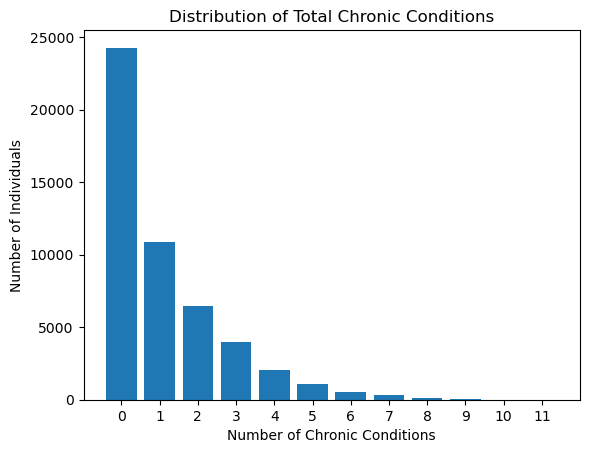

In [55]:
import matplotlib.pyplot as plt

# Count frequency of each chronic condition count
counts = df2["total_chronic_conditions"].value_counts().sort_index()

plt.figure()
plt.bar(counts.index, counts.values)
plt.xticks(counts.index)
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Number of Individuals")
plt.title("Distribution of Total Chronic Conditions")

plt.show()

### Creating age groups:

In [56]:
df2["age_group"] = pd.cut(
    df2["AGEY1X"],
    bins=[18, 30, 45, 60, 75, 120],
    labels=[1, 2, 3, 4, 5],   # ordinal numeric labels
    right=False
).astype(int)

df2["age_group"].head()

0    2
1    2
2    1
3    5
4    4
Name: age_group, dtype: int64

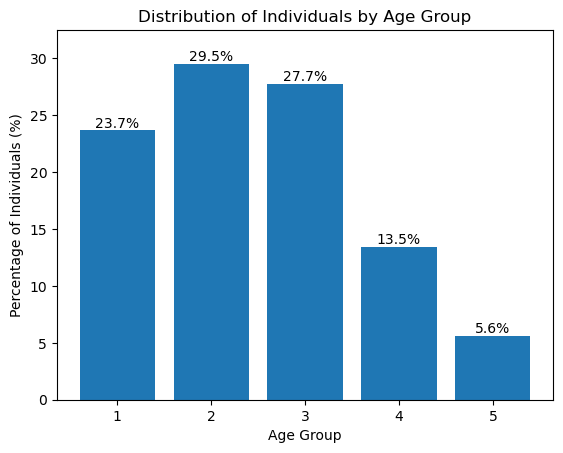

In [57]:
# Count age groups (keep logical order)
age_counts = df2["age_group"].value_counts().sort_index()

# Convert to percentage
age_percent = age_counts / age_counts.sum() * 100

plt.figure()
plt.bar(age_percent.index.astype(str), age_percent.values)

# Add percentage labels on bars
for i, v in enumerate(age_percent.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.xlabel("Age Group")
plt.ylabel("Percentage of Individuals (%)")
plt.title("Distribution of Individuals by Age Group")

plt.ylim(0, max(age_percent.values) * 1.1)  # Add slight headroom
plt.show()

### Creating BMI Category:

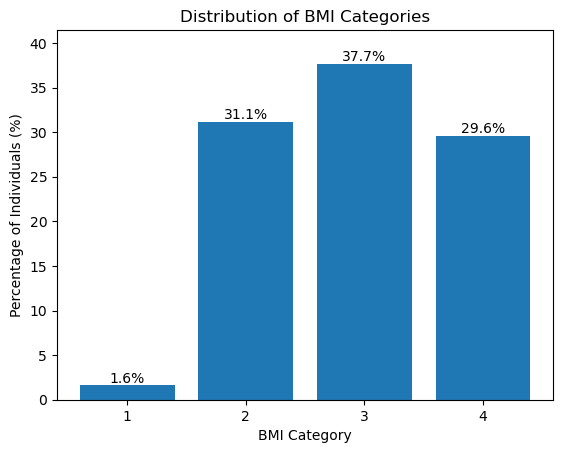

In [58]:
# Create BMI category using standard cutoffs
df2["bmi_category"] = pd.cut(
    df2["BMINDX5"],
    bins=[0, 18.5, 25, 30, 300],
    labels=[1, 2, 3, 4],   # 1=Underweight, 2=Normal, 3=Overweight, 4=Obese
    right=False
).astype(int)

import matplotlib.pyplot as plt

# Count BMI categories (keep logical order)
bmi_counts = df2["bmi_category"].value_counts().sort_index()

# Convert to percentage
bmi_percent = bmi_counts / bmi_counts.sum() * 100

# Plot
plt.figure()
plt.bar(bmi_percent.index.astype(str), bmi_percent.values)

# Add percentage labels
for i, v in enumerate(bmi_percent.values):
    plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom")

plt.xlabel("BMI Category")
plt.ylabel("Percentage of Individuals (%)")
plt.title("Distribution of BMI Categories")

plt.ylim(0, max(bmi_percent.values) * 1.1)  # Add headroom
plt.show()

### Inflation adjustment

In [59]:
cpi_dict = {
    2006: 201.6,
    2007: 207.3,
    2008: 215.3,
    2009: 214.5,
    2010: 218.1,
    2011: 224.9
}

base_cpi = cpi_dict[2011]

# Map CPI to each row based on BEGRFY1
df2["CPI_year"] = df2["BEGRFY1"].map(cpi_dict)

# Inflation multiplier to convert everything to 2011 dollars
df2["inflation_factor"] = base_cpi / df2["CPI_year"]

In [60]:
money_cols = [
    "TOTEXPY2", 'TOTEXPY1',
    'TOTSLFY1', 'TOTMCDY1', 'TOTMCRY1', 'TOTPRVY1', 'TOTTRIY1', 'TOTOPUY1'
]

for col in money_cols:
    if col in df2.columns:
        df2[col + "_adj"] = df2[col] * df2["inflation_factor"]

### Creating Inflation Adjusted Total Expense Category (Log Transformed)

In [61]:
df2["log_exp"] = np.log1p(df2["TOTEXPY2_adj"])

df2["TOTEXPY2_category"] = pd.qcut(df2["log_exp"], q=3)

df2["TOTEXPY2_category"].cat.categories

IntervalIndex([(-0.001, 5.337], (5.337, 7.634], (7.634, 13.252]], dtype='interval[float64, right]')

In [62]:
df2["log_exp"] = np.log1p(df2["TOTEXPY2_adj"])

df2["TOTEXPY2_category"] = pd.qcut(
    df2["log_exp"],
    q=[0, 0.5, 0.9, 1],
    labels=[0,1,2]
)

print(df2["TOTEXPY2_category"].value_counts())
print(df2["TOTEXPY2_category"].cat.categories)

TOTEXPY2_category
0    24910
1    19928
2     4982
Name: count, dtype: int64
Index([0, 1, 2], dtype='int64')


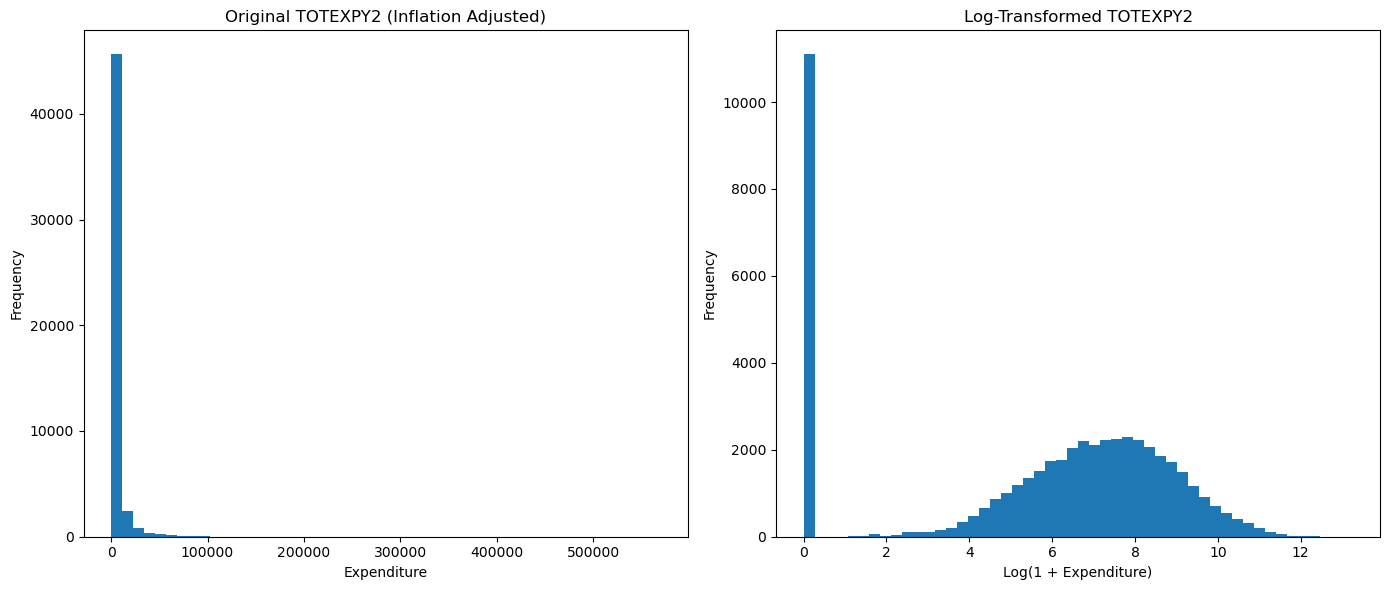

In [63]:
# Create side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original expenditure
axes[0].hist(df2["TOTEXPY2_adj"].dropna(), bins=50)
axes[0].set_title("Original TOTEXPY2 (Inflation Adjusted)")
axes[0].set_xlabel("Expenditure")
axes[0].set_ylabel("Frequency")

# Log-transformed expenditure
axes[1].hist(df2["log_exp"].dropna(), bins=50)
axes[1].set_title("Log-Transformed TOTEXPY2")
axes[1].set_xlabel("Log(1 + Expenditure)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [64]:
df2["TOTEXPY2_category"] = df2["TOTEXPY2_category"].cat.codes

In [65]:
df2["TOTEXPY2_category"].value_counts(normalize=True)

TOTEXPY2_category
0    0.5
1    0.4
2    0.1
Name: proportion, dtype: float64

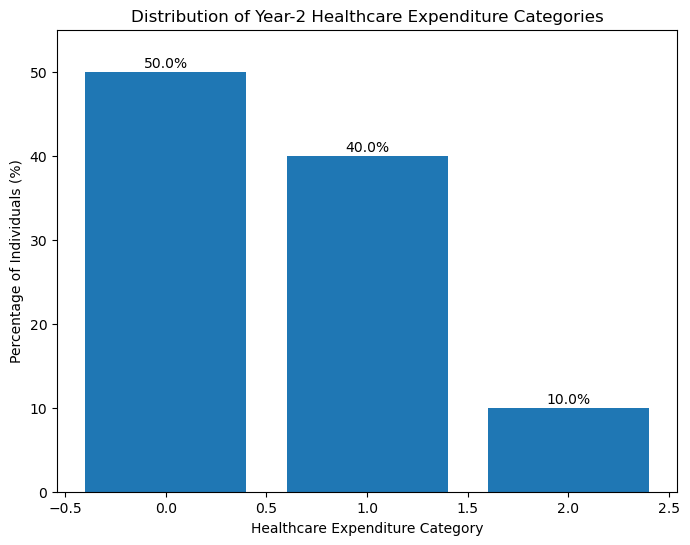

In [66]:
# Calculate percentage distribution
category_counts = df2["TOTEXPY2_category"].value_counts(normalize=True) * 100
category_counts = category_counts.sort_index()

# Plot
plt.figure(figsize=(8,6))
bars = plt.bar(category_counts.index, category_counts.values)

plt.ylabel("Percentage of Individuals (%)")
plt.xlabel("Healthcare Expenditure Category")
plt.title("Distribution of Year-2 Healthcare Expenditure Categories")

# Add percentage labels on top of bars
for i, value in enumerate(category_counts.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha='center')

plt.ylim(0, max(category_counts.values) + 5)
plt.grid(axis='y', linestyle='', alpha=0.5)

plt.show()

### Removing Unnecessary columns

In [67]:
# Drop columns
df2 = df2.drop(columns=['HIBPDXY1', 'CHDDXY1', 'ANGIDXY1', 'MIDXY1', 'OHRTDXY1','ARTHDXY1',
                        'ASTHDXY1', 'STRKDXY1', 'EMPHDXY1', 'CHOLDXY1', 'DIABDXY1',
                        'TOTSLFY1', 'TOTMCDY1', 'TOTMCRY1', 'TOTPRVY1', 'TOTTRIY1', 'TOTOPUY1'
                       ])
print(df2.shape)

(49820, 51)


In [68]:
df2 = df2.drop(columns=['CPI_year', 'inflation_factor'])
print(df2.shape)

(49820, 49)


### Binary Column Conversion

In [69]:
binary_cols = ['TRIEVY1', 'MCREVY1', 'MCDEVY1', 'PHYACT3', 'JTPAIN1', 'ADSMOK2']
df2[binary_cols] = df2[binary_cols].replace({1: 1, 2: 0})

In [70]:
df2["employed_flag"] = df2["EMPST1"].replace({1:1, 2:1, 3:1, 4:0})

### Data Encoding (One Hot Encoding)

In [71]:
# 1. Define nominal columns
#nominal_cols = ['SEX', 'RACETHNX', 'MARRYY1X', 'REGIONY1', 'INSCOVY1']

In [72]:
df2.columns

Index(['DUPERSID', 'PANEL', 'REGIONY1', 'BEGRFY1', 'AGEY1X', 'SEX', 'RACETHNX',
       'MARRYY1X', 'POVCATY1', 'RTHLTH1', 'MNHLTH1', 'VISION2', 'HEARNG2',
       'PHYACT3', 'BMINDX5', 'ADSMOK2', 'EMPST1', 'TRIEVY1', 'MCREVY1',
       'MCDEVY1', 'INSCOVY1', 'TOTEXPY1', 'TOTEXPY2', 'OBTOTVY1', 'OBDRVY1',
       'OBDEXPY1', 'OBTEXPY1', 'OPTOTVY1', 'ERTOTY1', 'IPDISY1', 'RXTOTY1',
       'RXEXPY1', 'JTPAIN1', 'OPTEXPY1', 'ERTEXPY1', 'IPTEXPY1',
       'total_chronic_conditions', 'age_group', 'bmi_category', 'TOTEXPY2_adj',
       'TOTEXPY1_adj', 'TOTSLFY1_adj', 'TOTMCDY1_adj', 'TOTMCRY1_adj',
       'TOTPRVY1_adj', 'TOTTRIY1_adj', 'TOTOPUY1_adj', 'log_exp',
       'TOTEXPY2_category', 'employed_flag'],
      dtype='object')

# Clustering

### Clinical Burden-Lifestyle Based Clustering

In [73]:
clinical_burden_cluster = [
    # Demographics
    'age_group', 'SEX', 'REGIONY1',
    # Health status
    'RTHLTH1', 'MNHLTH1', 'JTPAIN1', 'VISION2', 'HEARNG2',
    # Lifestyle
    'ADSMOK2', 'PHYACT3', 'bmi_category',
    # Chronic burden 
    'total_chronic_conditions'
]
df_cluster1 = df2[clinical_burden_cluster].copy()

# ---------------------------------
# One-Hot Encode Nominal Only
# ---------------------------------

nominal_cols = ['SEX', 'REGIONY1']

df_cluster_encoded = pd.get_dummies(
    df_cluster1,
    columns=nominal_cols,
    drop_first=True
)

# ---------------------------------
# Scale Everything
# ---------------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster_encoded)


In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)

sil_scores

{2: 0.16594852644905028,
 3: 0.11869859238279223,
 4: 0.14811033623789002,
 5: 0.15152065926334243,
 6: 0.12286750629094147}

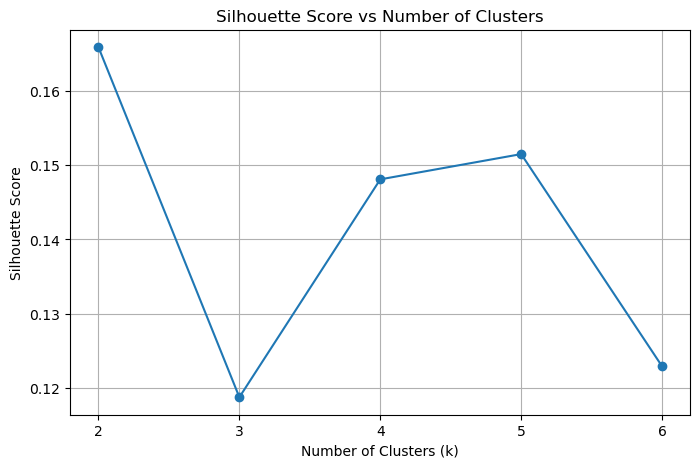

In [75]:
# Extract k values and scores
k_values = list(sil_scores.keys())
scores = list(sil_scores.values())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [76]:
optimal_k = 2
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df2["clinical_burden_cluster"] = kmeans_final.fit_predict(X_scaled)
df2["clinical_burden_cluster"].value_counts()

clinical_burden_cluster
1    33011
0    16809
Name: count, dtype: int64

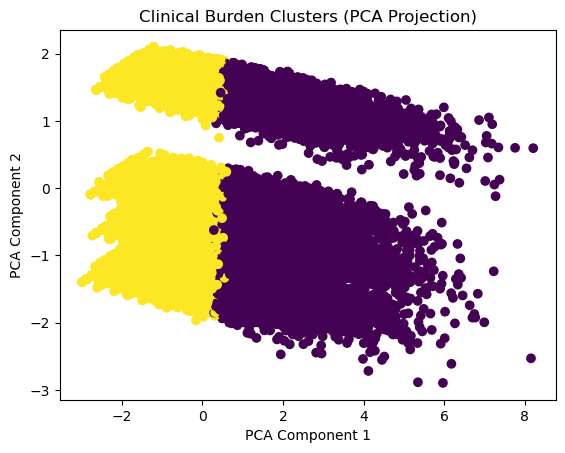

In [77]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure()
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df2["clinical_burden_cluster"],
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clinical Burden Clusters (PCA Projection)")
plt.show()

In [78]:
cluster_profile = (
    df2
    .groupby("clinical_burden_cluster")[clinical_burden_cluster]
    .mean()
    .round(2)
)

cluster_sizes = df2["clinical_burden_cluster"].value_counts().sort_index()
cluster_profile["cluster_size"] = cluster_sizes.values

binary_cols = ['JTPAIN1', 'ADSMOK2', 'PHYACT3']
cluster_profile[binary_cols] = (
    cluster_profile[binary_cols] * 100
).round(1)

cluster_profile

,age_group,SEX,REGIONY1,RTHLTH1,MNHLTH1,JTPAIN1,VISION2,HEARNG2,ADSMOK2,PHYACT3,bmi_category,total_chronic_conditions,cluster_size
clinical_burden_cluster,,,,,,,,,,,,,
0,3.33,1.58,2.68,3.28,2.61,54.0,1.19,1.18,22.0,42.0,3.22,2.55,16809
1,2.04,1.51,2.80,1.91,1.66,9.0,1.03,1.02,16.0,63.0,2.81,0.43,33011


### Utilization-Based Clustering

# Saving the data frame into CSV file:

In [79]:
# Export final analytic dataset to CSV
df2.to_csv(
    "Z:/NEU/ALY 6980 - Capstone Project/outputs/MEPS_Final.csv",
    index=False
)

# EDA

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [81]:
df2.columns

Index(['DUPERSID', 'PANEL', 'REGIONY1', 'BEGRFY1', 'AGEY1X', 'SEX', 'RACETHNX',
       'MARRYY1X', 'POVCATY1', 'RTHLTH1', 'MNHLTH1', 'VISION2', 'HEARNG2',
       'PHYACT3', 'BMINDX5', 'ADSMOK2', 'EMPST1', 'TRIEVY1', 'MCREVY1',
       'MCDEVY1', 'INSCOVY1', 'TOTEXPY1', 'TOTEXPY2', 'OBTOTVY1', 'OBDRVY1',
       'OBDEXPY1', 'OBTEXPY1', 'OPTOTVY1', 'ERTOTY1', 'IPDISY1', 'RXTOTY1',
       'RXEXPY1', 'JTPAIN1', 'OPTEXPY1', 'ERTEXPY1', 'IPTEXPY1',
       'total_chronic_conditions', 'age_group', 'bmi_category', 'TOTEXPY2_adj',
       'TOTEXPY1_adj', 'TOTSLFY1_adj', 'TOTMCDY1_adj', 'TOTMCRY1_adj',
       'TOTPRVY1_adj', 'TOTTRIY1_adj', 'TOTOPUY1_adj', 'log_exp',
       'TOTEXPY2_category', 'employed_flag', 'clinical_burden_cluster'],
      dtype='object')

In [82]:
# Copy to avoid modifying original
df_plot = df2.copy()

C:\Users\kumar\AppData\Local\Temp\ipykernel_48472\3877901885.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Age_Group_Label','Sex_Label'])['total_chronic_conditions']
C:\Users\kumar\AppData\Local\Temp\ipykernel_48472\3877901885.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Age_Group_Label','Sex_Label'])['TOTEXPY1_adj']


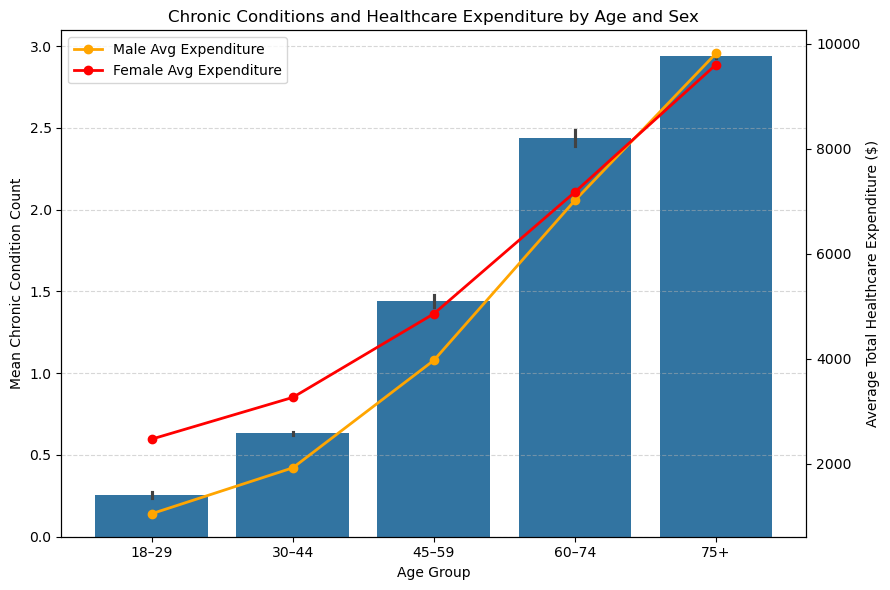

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# Age labels
# -------------------------------
age_map = {
    1: '18–29',
    2: '30–44',
    3: '45–59',
    4: '60–74',
    5: '75+'
}

df_plot['Age_Group_Label'] = df_plot['age_group'].map(age_map)

age_order = ['18–29', '30–44', '45–59', '60–74', '75+']

df_plot['Age_Group_Label'] = pd.Categorical(
    df_plot['Age_Group_Label'],
    categories=age_order,
    ordered=True
)

# -------------------------------
# Sex labels
# -------------------------------
sex_map = {
    1: 'Male',
    2: 'Female'
}

df_plot['Sex_Label'] = df_plot['SEX'].map(sex_map)

# -------------------------------
# Mean chronic conditions
# -------------------------------
age_sex = (
    df_plot
    .dropna(subset=['Age_Group_Label','Sex_Label','total_chronic_conditions'])
    .groupby(['Age_Group_Label','Sex_Label'])['total_chronic_conditions']
    .mean()
    .reset_index()
)

# -------------------------------
# Mean expenditure by age and sex
# -------------------------------
age_exp = (
    df_plot
    .dropna(subset=['Age_Group_Label','Sex_Label','TOTEXPY1_adj'])
    .groupby(['Age_Group_Label','Sex_Label'])['TOTEXPY1_adj']
    .mean()
    .reset_index()
)

# -------------------------------
# Plot
# -------------------------------
fig, ax1 = plt.subplots(figsize=(9,6))

# BARPLOT (Chronic conditions)
sns.barplot(
    data=age_sex,
    x='Age_Group_Label',
    y='total_chronic_conditions',
    ax=ax1
)

ax1.set_ylabel('Mean Chronic Condition Count')
ax1.set_xlabel('Age Group')
ax1.set_title('Chronic Conditions and Healthcare Expenditure by Age and Sex')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# -------------------------------
# SECONDARY AXIS (Expenditure)
# -------------------------------
ax2 = ax1.twinx()

for sex, color in zip(['Male','Female'], ['orange','red']):
    
    temp = age_exp[age_exp['Sex_Label'] == sex]
    
    ax2.plot(
        temp['Age_Group_Label'],
        temp['TOTEXPY1_adj'],
        marker='o',
        linewidth=2,
        label=f'{sex} Avg Expenditure',
        color=color
    )

ax2.set_ylabel('Average Total Healthcare Expenditure ($)')

# Legends
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

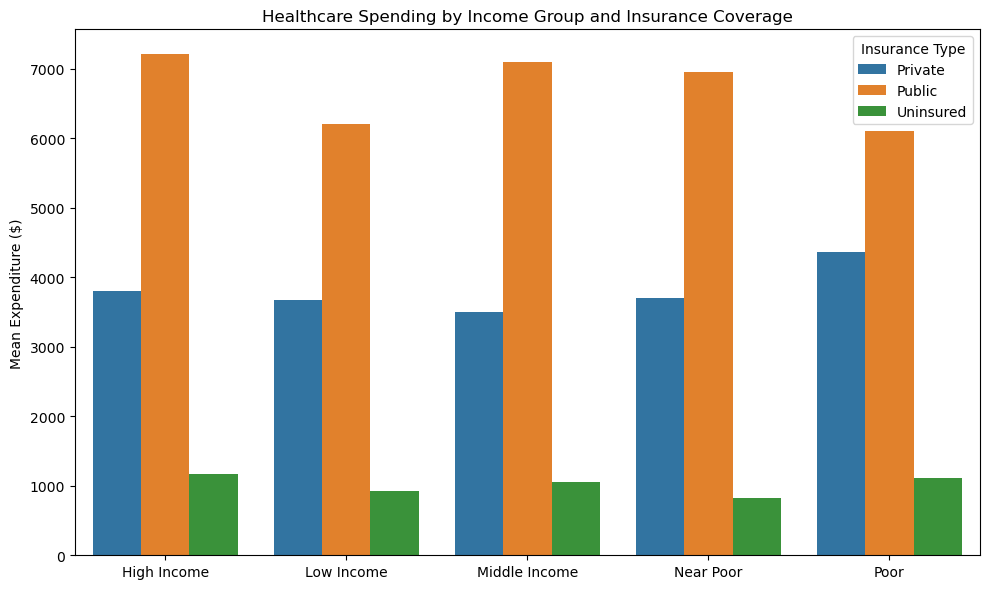

In [84]:
# Drop missing
df_plot = df_plot.dropna(subset=['TOTEXPY1', 'POVCATY1', 'INSCOVY1'])

# ---- Map Poverty Category ----
pov_map = {
    1: 'Poor',
    2: 'Near Poor',
    3: 'Low Income',
    4: 'Middle Income',   # adjust if needed based on MEPS coding
    5: 'High Income'
}

df_plot['Income_Group'] = df_plot['POVCATY1'].map(pov_map)

# ---- Map Insurance Coverage ----
ins_map = {
    1: 'Private',
    2: 'Public',
    3: 'Uninsured'
}

df_plot['Insurance_Type'] = df_plot['INSCOVY1'].map(ins_map)

# median because healthcare spending is heavily skewed.
median_data = (
    df_plot
    .groupby(['Income_Group','Insurance_Type'])['TOTEXPY1']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=median_data,
    x='Income_Group',
    y='TOTEXPY1',
    hue='Insurance_Type'
)

plt.title('Healthcare Spending by Income Group and Insurance Coverage')
plt.ylabel('Mean Expenditure ($)')
plt.xlabel('')
plt.legend(title='Insurance Type')
plt.tight_layout()
plt.show()


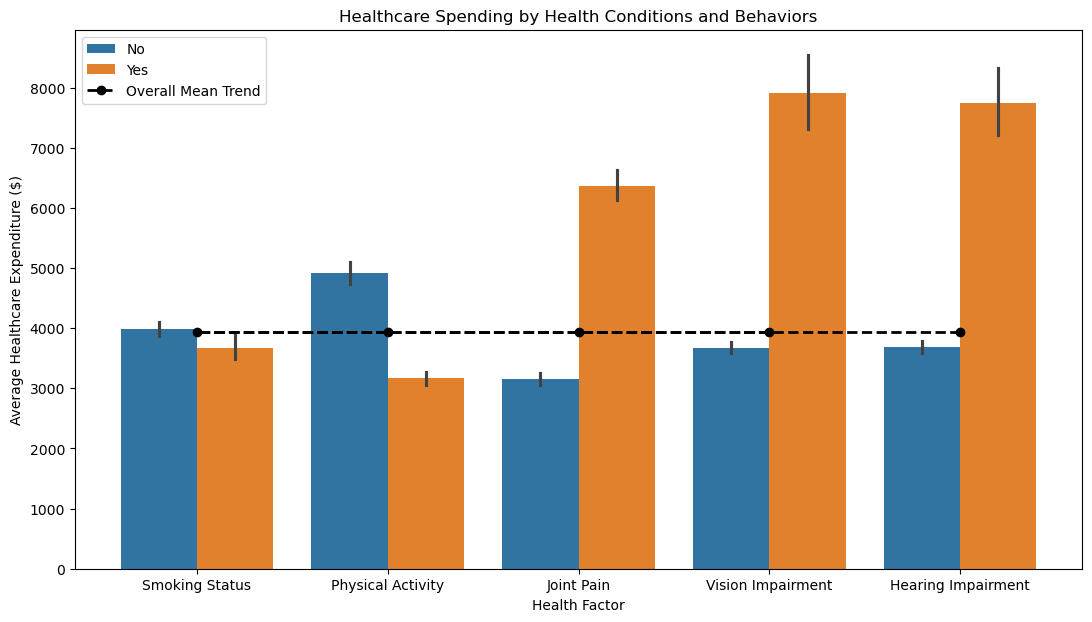

In [137]:
vision_map = {
    1: 0,
    2: 1,
    3: 1,
    4: 1,
    5: 1
}

df_plot['VISION_BIN'] = df_plot['VISION2'].map(vision_map)
df_plot['HEARING_BIN'] = df_plot['HEARNG2'].map(vision_map)

cols = ['ADSMOK2', 'PHYACT3', 'JTPAIN1', 'VISION_BIN', 'HEARING_BIN']

df_melt = df_plot.melt(
    id_vars='TOTEXPY1_adj',
    value_vars=cols,
    var_name='Health_Factor',
    value_name='Category'
)

factor_labels = {
    'ADSMOK2': 'Smoking Status',
    'PHYACT3': 'Physical Activity',
    'JTPAIN1': 'Joint Pain',
    'VISION_BIN': 'Vision Impairment',
    'HEARING_BIN': 'Hearing Impairment'
}

df_melt['Health_Factor'] = df_melt['Health_Factor'].map(factor_labels)

df_melt['Category'] = df_melt['Category'].map({
    0: 'No',
    1: 'Yes'
})

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(13,7))

ax = sns.barplot(
    data=df_melt,
    x='Health_Factor',
    y='TOTEXPY1_adj',
    hue='Category',
    estimator=np.mean
)

# Calculate mean for dotted line
line_data = (
    df_melt
    .groupby('Health_Factor')['TOTEXPY1_adj']
    .mean()
    .reset_index()
)

plt.plot(
    line_data['Health_Factor'],
    line_data['TOTEXPY1_adj'],
    linestyle='--',
    marker='o',
    color='black',
    linewidth=2,
    label='Overall Mean Trend'
)

plt.ylabel('Average Healthcare Expenditure ($)')
plt.xlabel('Health Factor')
plt.title('Healthcare Spending by Health Conditions and Behaviors')

plt.legend()
plt.show()

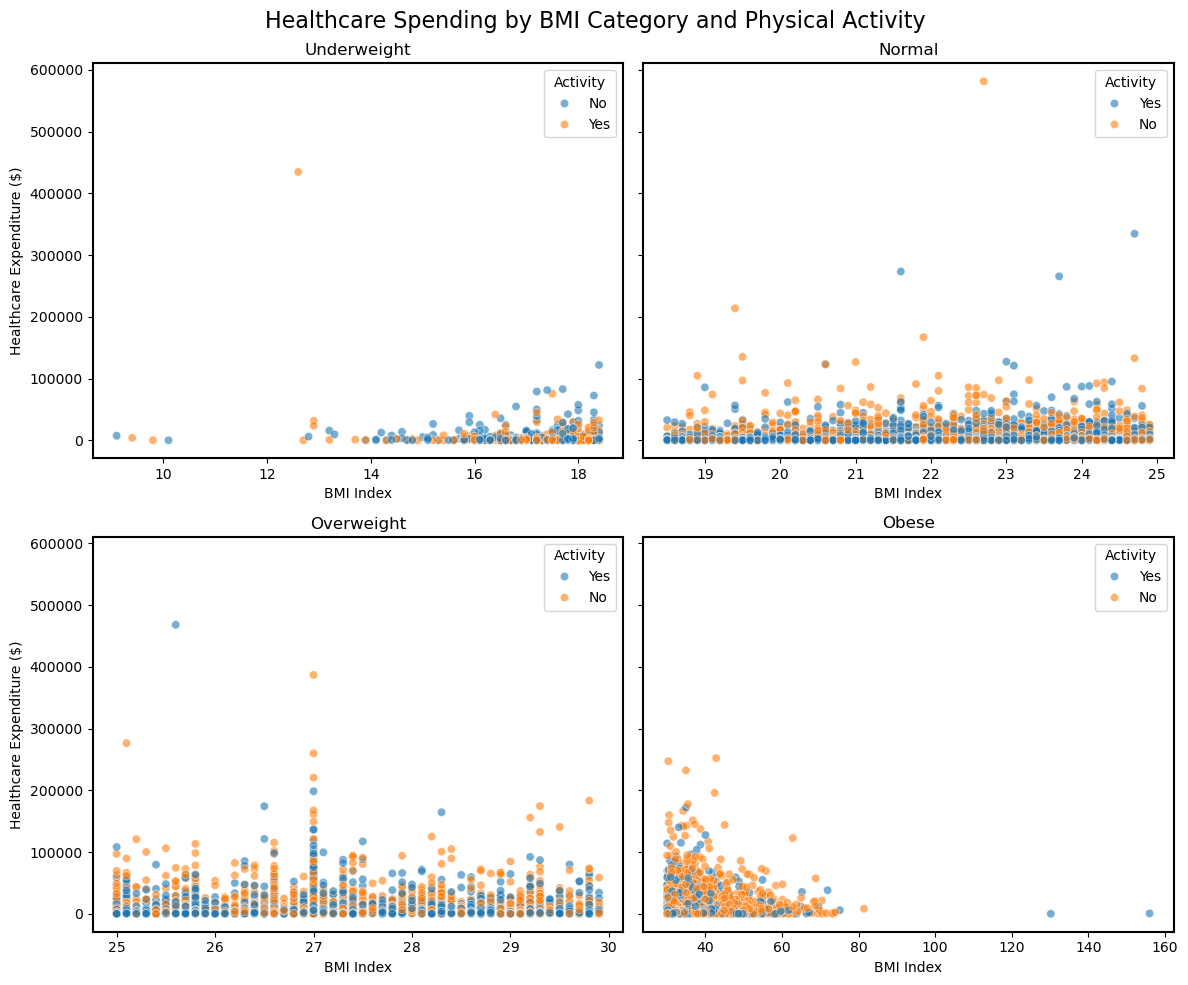

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------
# Map Activity
# ---------------------------
activity_map = {
    1: 'Yes',
    0: 'No'
}

df_plot['Activity_Level'] = df_plot['PHYACT3'].map(activity_map)

# ---------------------------
# Map BMI category labels
# ---------------------------
bmi_labels = {
    1: 'Underweight',
    2: 'Normal',
    3: 'Overweight',
    4: 'Obese'
}

df_plot['BMI_Category_Label'] = df_plot['bmi_category'].map(bmi_labels)

# ---------------------------
# Force BMI order
# ---------------------------
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']

df_plot['BMI_Category_Label'] = pd.Categorical(
    df_plot['BMI_Category_Label'],
    categories=bmi_order,
    ordered=True
)

# ---------------------------
# Create 2x2 subplot grid
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10), sharey=True)

axes = axes.flatten()

for i, bmi in enumerate(bmi_order):
    
    ax = axes[i]
    
    temp = df_plot[df_plot['BMI_Category_Label'] == bmi]
    
    sns.scatterplot(
        data=temp,
        x="BMINDX5",
        y="TOTEXPY1_adj",
        hue="Activity_Level",
        alpha=0.6,
        ax=ax
    )
    
    ax.set_title(bmi)
    
    # Add border around subplot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
    
    # Individual legend
    ax.legend(title="Activity", loc='upper right')

# Axis labels
for ax in axes:
    ax.set_xlabel("BMI Index")
    ax.set_ylabel("Healthcare Expenditure ($)")

plt.suptitle(
    "Healthcare Spending by BMI Category and Physical Activity",
    fontsize=16
)

plt.tight_layout()
plt.show()

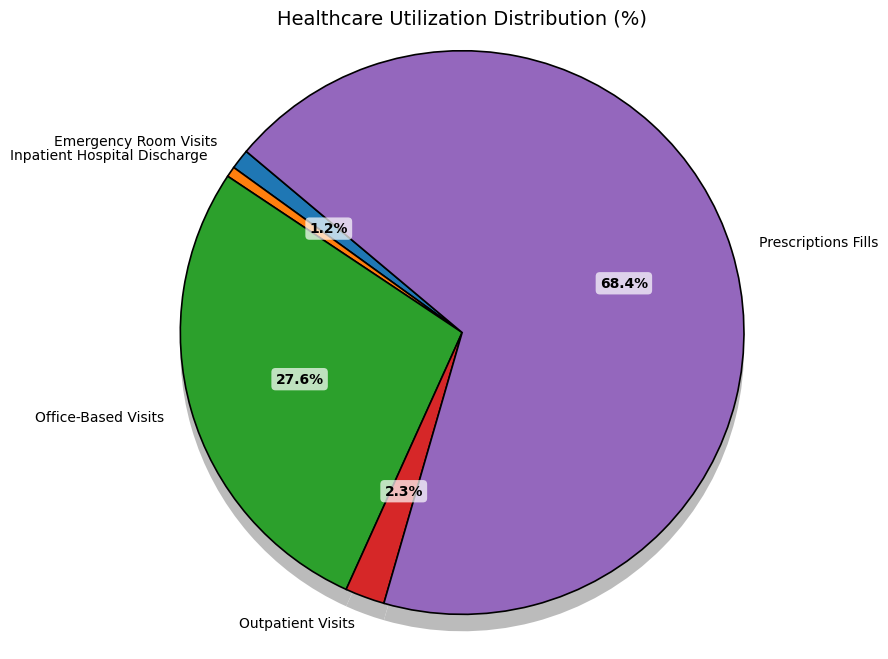

In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Utilization Columns
# ---------------------------
util_cols = [
    'OPTOTVY1',
    'IPDISY1',
    'RXTOTY1',
    'ERTOTY1',
    'OBTOTVY1'
]

# ---------------------------
# Melt the Data
# ---------------------------
util_melted = df_plot.melt(
    value_vars=util_cols,
    var_name='Utilization_Type',
    value_name='Count'
)

# ---------------------------
# Aggregate Total Counts
# ---------------------------
util_summary = (
    util_melted
    .groupby('Utilization_Type')['Count']
    .sum()
    .reset_index()
)

# ---------------------------
# Convert to Percentage
# ---------------------------
util_summary['Percentage'] = (
    util_summary['Count'] / util_summary['Count'].sum()
) * 100

# ---------------------------
# Rename Labels
# ---------------------------
label_map = {
    'OPTOTVY1': 'Outpatient Visits',
    'IPDISY1': 'Inpatient Hospital Discharge',
    'RXTOTY1': 'Prescriptions Fills',
    'ERTOTY1': 'Emergency Room Visits',
    'OBTOTVY1': 'Office-Based Visits'
}

util_summary['Utilization_Type'] = util_summary['Utilization_Type'].map(label_map)

# ---------------------------
# Plot 3D-style Pie
# ---------------------------
fig, ax = plt.subplots(figsize=(8,8))

# Bottom shadow layer (depth illusion)
ax.pie(
    util_summary['Percentage'],
    radius=1,
    startangle=140,
    colors=['#bbbbbb'] * len(util_summary),
    wedgeprops=dict(edgecolor='none'),
    center=(0, -0.06)
)

# Top layer (main pie)
wedges, texts = ax.pie(
    util_summary['Percentage'],
    labels=util_summary['Utilization_Type'],  # show names
    startangle=140,
    wedgeprops=dict(edgecolor='black', linewidth=1.2)  # black borders
)

# ---------------------------
# Add centered % labels
# ---------------------------
for i, w in enumerate(wedges):
    pct = util_summary['Percentage'].iloc[i]
    
    # Skip % text if < 1%
    if pct < 1:
        continue

    angle = (w.theta2 + w.theta1) / 2
    x = 0.6 * np.cos(np.deg2rad(angle))
    y = 0.6 * np.sin(np.deg2rad(angle))

    ax.text(
        x, y,
        f"{pct:.1f}%",
        ha='center', va='center',
        fontsize=10, weight='bold',
        bbox=dict(
            facecolor='white',
            alpha=0.7,        # transparent white box
            edgecolor='none',
            boxstyle='round,pad=0.3'
        )
    )

# ---------------------------
# Title & Layout
# ---------------------------
ax.set_title('Healthcare Utilization Distribution (%)', fontsize=14)

plt.axis('equal')
plt.show()

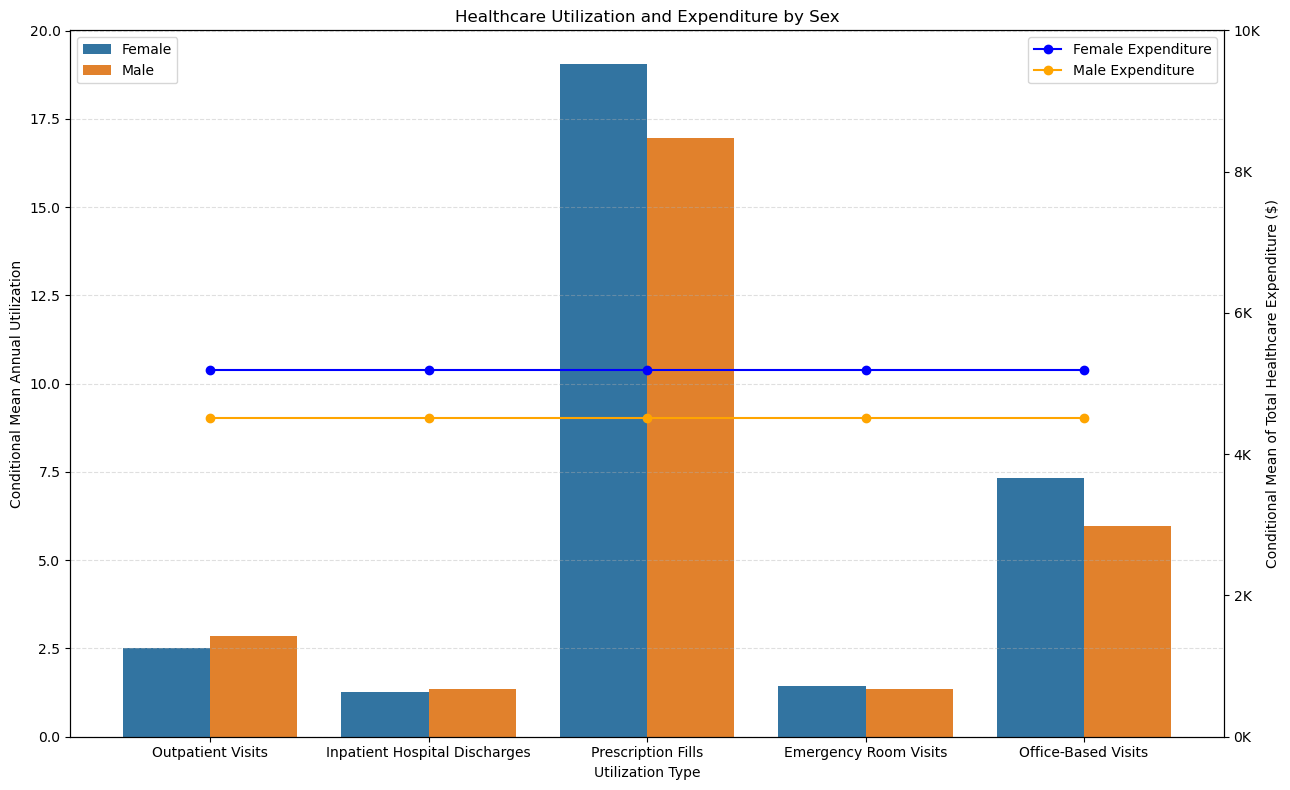

In [101]:
# -------------------------------
# Map Sex labels
# -------------------------------
sex_map = {
    1: 'Male',
    2: 'Female'
}

df_plot['Sex_Label'] = df_plot['SEX'].map(sex_map)

# -------------------------------
# Utilization Variables
# -------------------------------
util_cols = [
    'OPTOTVY1',  # Outpatient visits
    'IPDISY1',  # Inpatient Discharge
    'RXTOTY1',   # Prescriptions filled
    'ERTOTY1',   # ER visits
    'OBTOTVY1'   # office-based visits
]

# -------------------------------
# Readable Labels
# -------------------------------
util_labels = {
    'OPTOTVY1': 'Outpatient Visits',
    'IPDISY1': 'Inpatient Hospital Discharges',
    'RXTOTY1': 'Prescription Fills',
    'ERTOTY1': 'Emergency Room Visits',
    'OBTOTVY1': 'Office-Based Visits'
}

# -------------------------------
# Utilization Aggregation
# -------------------------------
util_sex = (
    df_plot
    .groupby('Sex_Label')[util_cols]
    .agg(lambda x: x[x > 0].mean())
    .reset_index()
)

# -------------------------------
# Expenditure Aggregation
# -------------------------------
exp_sex = (
    df_plot
    .groupby('Sex_Label')['TOTEXPY1_adj']
    .agg(lambda x: x[x > 0].mean())
    .reset_index()
)

# -------------------------------
# Melt for plotting
# -------------------------------
util_melted = util_sex.melt(
    id_vars='Sex_Label',
    value_vars=util_cols,
    var_name='Utilization_Type',
    value_name='Mean_Visits'
)

util_melted['Utilization_Type'] = util_melted['Utilization_Type'].map(util_labels)

# -------------------------------
# Plot
# -------------------------------
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig, ax1 = plt.subplots(figsize=(13,8))

# BARPLOT (Utilization)
sns.barplot(
    data=util_melted,
    x='Utilization_Type',
    y='Mean_Visits',
    hue='Sex_Label',
    ax=ax1
)

ax1.set_ylabel('Conditional Mean Annual Utilization')
ax1.set_xlabel('Utilization Type')
ax1.set_title('Healthcare Utilization and Expenditure by Sex')

ax1.tick_params(axis='x', rotation=0)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------
# SECOND AXIS FOR EXPENDITURE
# -------------------------------
ax2 = ax1.twinx()

x_positions = range(len(util_labels))

male_exp = exp_sex.loc[exp_sex['Sex_Label']=='Male','TOTEXPY1_adj'].values[0]
female_exp = exp_sex.loc[exp_sex['Sex_Label']=='Female','TOTEXPY1_adj'].values[0]

ax2.plot(
    x_positions,
    [female_exp]*len(x_positions),
    color='blue',
    marker='o',
    label='Female Expenditure'
)

ax2.plot(
    x_positions,
    [male_exp]*len(x_positions),
    color='orange',
    marker='o',
    label='Male Expenditure'
)

ax2.set_ylabel('Conditional Mean of Total Healthcare Expenditure ($)')

# Set secondary axis range from 0 to 10K
ax2.set_ylim(0, 10000)

# Set tick locations
ax2.set_yticks(range(0, 10001, 2000))

# Format tick labels as K
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

# Legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

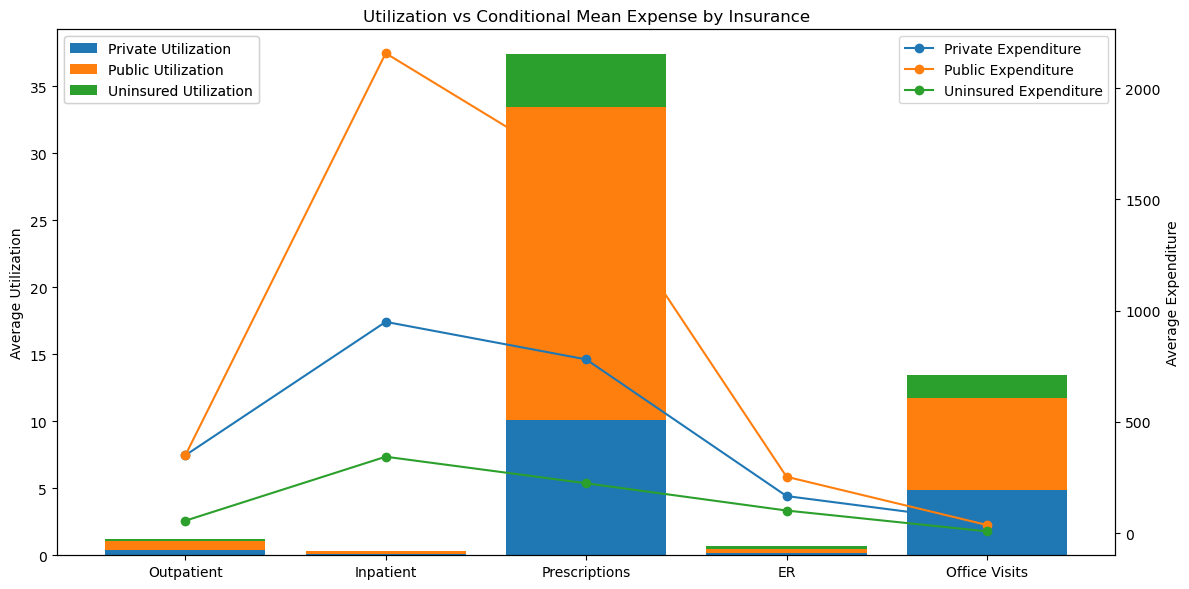

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Maps
# -------------------------------
ins_map = {
    1: 'Private',
    2: 'Public',
    3: 'Uninsured'
}

util_cols = [
    'OPTOTVY1',   # Outpatient visits
    'IPDISY1',    # Inpatient discharge
    'RXTOTY1',    # Prescriptions
    'ERTOTY1',    # ER visits
    'OBTOTVY1'    # Office visits
]

util_exp_col = [
    'OPTEXPY1',
    'IPTEXPY1',
    'RXEXPY1',
    'ERTEXPY1',
    'OBTEXPY1'
]

util_labels = {
    'OPTOTVY1': 'Outpatient',
    'IPDISY1': 'Inpatient',
    'RXTOTY1': 'Prescriptions',
    'ERTOTY1': 'ER',
    'OBTOTVY1': 'Office Visits'
}

# -------------------------------
# Insurance Mapping
# -------------------------------
df_plot['Insurance_Type'] = df_plot['INSCOVY1'].map(ins_map)

# -------------------------------
# Create Aggregated Data
# -------------------------------
plot_data = []

for util, exp in zip(util_cols, util_exp_col):
    
    temp = (
        df_plot
        .groupby('Insurance_Type')
        .agg(
            avg_util=(util, 'mean'),
            avg_exp=(exp, 'mean')
        )
        .reset_index()
    )
    
    temp['Utilization_Type'] = util_labels[util]
    plot_data.append(temp)

plot_df = pd.concat(plot_data, ignore_index=True)

# -------------------------------
# FIX ORDER (CRITICAL)
# -------------------------------
order = [util_labels[u] for u in util_cols]

plot_df['Utilization_Type'] = pd.Categorical(
    plot_df['Utilization_Type'],
    categories=order,
    ordered=True
)

plot_df = plot_df.sort_values('Utilization_Type')

# -------------------------------
# Pivot for stacked bars
# -------------------------------
util_pivot = plot_df.pivot(
    index='Utilization_Type',
    columns='Insurance_Type',
    values='avg_util'
)

# Ensure correct order
util_pivot = util_pivot.loc[order]

# -------------------------------
# Plot
# -------------------------------
fig, ax1 = plt.subplots(figsize=(12, 6))

# -------------------------------
# Stacked Bar (Utilization)
# -------------------------------
bottom = np.zeros(len(util_pivot))

for col in util_pivot.columns:
    ax1.bar(
        util_pivot.index,
        util_pivot[col],
        bottom=bottom,
        label=f'{col} Utilization'
    )
    bottom += util_pivot[col].values

# -------------------------------
# Line Plot (Expenditure)
# -------------------------------
ax2 = ax1.twinx()

for ins in plot_df['Insurance_Type'].unique():
    subset = plot_df[plot_df['Insurance_Type'] == ins]
    
    subset = subset.sort_values('Utilization_Type')  # critical
    
    ax2.plot(
        subset['Utilization_Type'],
        subset['avg_exp'],
        marker='o',
        linestyle='-',
        label=f'{ins} Expenditure'
    )

# -------------------------------
# Labels & Title
# -------------------------------
ax1.set_ylabel('Average Utilization')
ax2.set_ylabel('Average Expenditure')

ax1.set_title('Utilization vs Conditional Mean Expense by Insurance')

plt.xticks(rotation=30)

# -------------------------------
# Separate Legends
# -------------------------------
legend1 = ax1.legend(loc='upper left')   # bars
legend2 = ax2.legend(loc='upper right')  # lines

ax1.add_artist(legend1)

# -------------------------------
# Final Layout
# -------------------------------
plt.tight_layout()
plt.show()

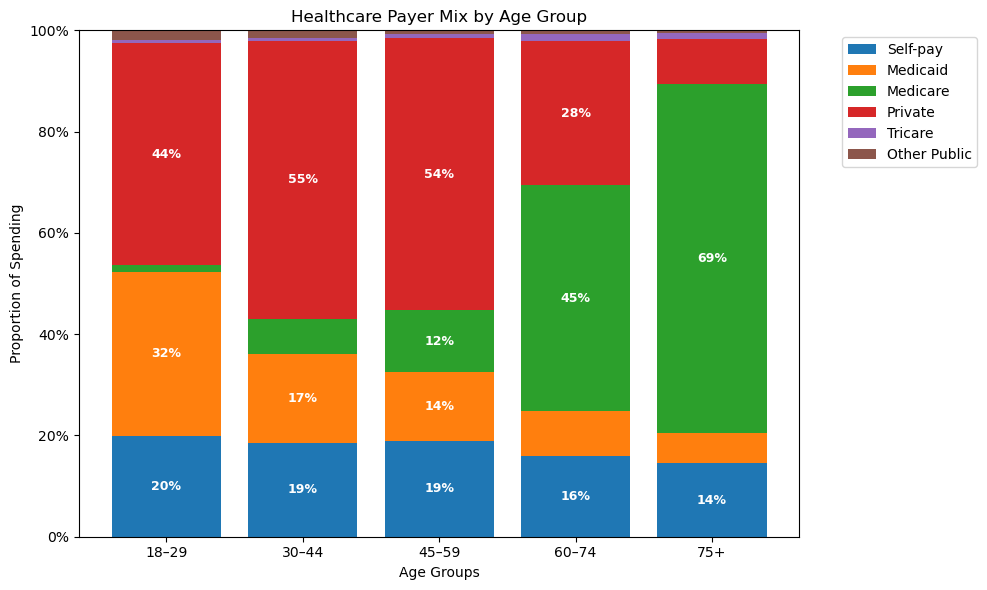

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --------------------------------------------------
# 1. Map Age Groups
# --------------------------------------------------

age_map = {
    1: '18–29',
    2: '30–44',
    3: '45–59',
    4: '60–74',
    5: '75+'
}

df_plot['Age_Group_Label'] = df_plot['age_group'].map(age_map)

age_order = ['18–29','30–44','45–59','60–74','75+']

df_plot['Age_Group_Label'] = pd.Categorical(
    df_plot['Age_Group_Label'],
    categories=age_order,
    ordered=True
)

# --------------------------------------------------
# 2. Aggregate payer spending
# --------------------------------------------------

payer_cols = [
    'TOTSLFY1_adj',
    'TOTMCDY1_adj',
    'TOTMCRY1_adj',
    'TOTPRVY1_adj',
    'TOTTRIY1_adj',
    'TOTOPUY1_adj'
]

age_payer = (
    df_plot
    .groupby('Age_Group_Label', observed=False)[payer_cols]
    .sum()
)

# --------------------------------------------------
# 3. Convert to proportions
# --------------------------------------------------

age_payer["Total"] = age_payer.sum(axis=1)

age_payer_prop = age_payer[payer_cols].div(age_payer["Total"], axis=0)

age_payer_prop.columns = [
    'Self-pay',
    'Medicaid',
    'Medicare',
    'Private',
    'Tricare',
    'Other Public'
]

# --------------------------------------------------
# 4. Plot stacked 100% bar chart
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(age_payer_prop.index))
bottom = np.zeros(len(age_payer_prop.index))

for col in age_payer_prop.columns:

    values = age_payer_prop[col].to_numpy()

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=col
    )

    # Add % labels only if >10%
    for i, v in enumerate(values):
        if v > 0.10:
            ax.text(
                x[i],
                bottom[i] + v/2,
                f"{v*100:.0f}%",
                ha='center',
                va='center',
                color='white',
                fontsize=9,
                fontweight='bold'
            )

    bottom += values

# --------------------------------------------------
# 5. Formatting
# --------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(age_payer_prop.index)

ax.set_title('Healthcare Payer Mix by Age Group')
ax.set_ylabel('Proportion of Spending')
ax.set_xlabel('Age Groups')

ax.set_ylim(0,1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()

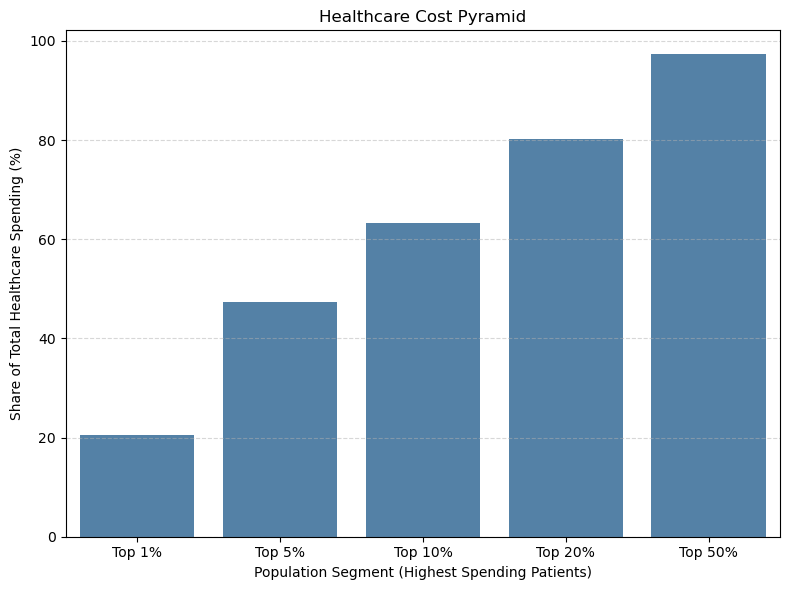

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Prepare expenditure data
# -------------------------------
df_cost = df_plot[['TOTEXPY1_adj']].dropna().copy()

# Sort patients by expenditure (highest first)
df_cost = df_cost.sort_values(by='TOTEXPY1_adj', ascending=False).reset_index(drop=True)

# Total healthcare spending
total_spending = df_cost['TOTEXPY1_adj'].sum()

# -------------------------------
# Define population segments
# -------------------------------
segments = {
    "Top 1%": int(len(df_cost)*0.01),
    "Top 5%": int(len(df_cost)*0.05),
    "Top 10%": int(len(df_cost)*0.10),
    "Top 20%": int(len(df_cost)*0.20),
    "Top 50%": int(len(df_cost)*0.50)
}

# Calculate spending share
results = []

for seg, n in segments.items():
    
    spending = df_cost.head(n)['TOTEXPY1_adj'].sum()
    share = (spending / total_spending) * 100
    
    results.append({
        "Population Segment": seg,
        "Spending Share (%)": share
    })

cost_pyramid = pd.DataFrame(results)

# -------------------------------
# Plot Healthcare Cost Pyramid
# -------------------------------
plt.figure(figsize=(8,6))

sns.barplot(
    data=cost_pyramid,
    x="Population Segment",
    y="Spending Share (%)",
    color="steelblue"
)

plt.title("Healthcare Cost Pyramid")
plt.xlabel("Population Segment (Highest Spending Patients)")
plt.ylabel("Share of Total Healthcare Spending (%)")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Predictive Modeling

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

In [108]:
target = 'TOTEXPY2_category'

features = [
 'REGIONY1',  'AGEY1X', 'SEX', 'RACETHNX',
 'MARRYY1X', 'POVCATY1', 'employed_flag',
 'RTHLTH1', 'MNHLTH1', 'VISION2', 'HEARNG2',
 'PHYACT3', 'ADSMOK2', 'TRIEVY1', 'MCREVY1',
 'MCDEVY1', 'INSCOVY1',
    'OBTOTVY1', 'OPTOTVY1', 'ERTOTY1', 'IPDISY1', 'RXTOTY1', 'JTPAIN1',
 'total_chronic_conditions',  'bmi_category', 'TOTEXPY1_adj',
 'TOTSLFY1_adj', 'TOTMCDY1_adj',
 'TOTMCRY1_adj', 'TOTPRVY1_adj',
 'TOTTRIY1_adj', 'TOTOPUY1_adj', 'clinical_burden_cluster'
]

df_model = df2.dropna(subset=features + [target])

X = df_model[features]
y = df_model[target]



In [109]:
nominal_cols = ['SEX', 'RACETHNX', 'MARRYY1X', 'REGIONY1', 'INSCOVY1']
num_cols = [col for col in features if col not in nominal_cols]
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols)
    ]
)

In [110]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [111]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))

In [112]:
log_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        max_iter=2000
    ))
])

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("LOGISTIC REGRESSION (RIDGE)")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


C:\Users\kumar\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


LOGISTIC REGRESSION (RIDGE)
Accuracy: 0.7119630670413488

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.87      0.80      7473
           1       0.67      0.64      0.66      5978
           2       0.70      0.21      0.33      1495

    accuracy                           0.71     14946
   macro avg       0.70      0.57      0.59     14946
weighted avg       0.71      0.71      0.69     14946


Confusion Matrix:

[[6475  989    9]
 [2001 3847  130]
 [ 248  928  319]]


In [113]:
rf_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=150,
        n_jobs=-1,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("RANDOM FOREST")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

RANDOM FOREST
Accuracy: 0.720125786163522

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.84      0.80      7473
           1       0.66      0.69      0.67      5978
           2       0.68      0.26      0.38      1495

    accuracy                           0.72     14946
   macro avg       0.70      0.60      0.62     14946
weighted avg       0.72      0.72      0.71     14946


Confusion Matrix:

[[6254 1206   13]
 [1686 4117  175]
 [ 203  900  392]]


In [114]:
gb_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

print("GRADIENT BOOSTING")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

GRADIENT BOOSTING
Accuracy: 0.7203265087648869

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.83      0.80      7473
           1       0.66      0.69      0.68      5978
           2       0.66      0.27      0.38      1495

    accuracy                           0.72     14946
   macro avg       0.70      0.60      0.62     14946
weighted avg       0.72      0.72      0.71     14946


Confusion Matrix:

[[6239 1221   13]
 [1658 4127  193]
 [ 208  887  400]]


In [115]:
xgb_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y)),
        eval_metric='mlogloss',
        tree_method='hist',
        n_estimators=150,
        learning_rate=0.05,
        n_jobs=-1,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("XGBOOST")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

XGBOOST
Accuracy: 0.7221330121771712

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.84      0.80      7473
           1       0.67      0.68      0.68      5978
           2       0.66      0.27      0.38      1495

    accuracy                           0.72     14946
   macro avg       0.70      0.60      0.62     14946
weighted avg       0.72      0.72      0.71     14946


Confusion Matrix:

[[6312 1148   13]
 [1699 4082  197]
 [ 218  878  399]]


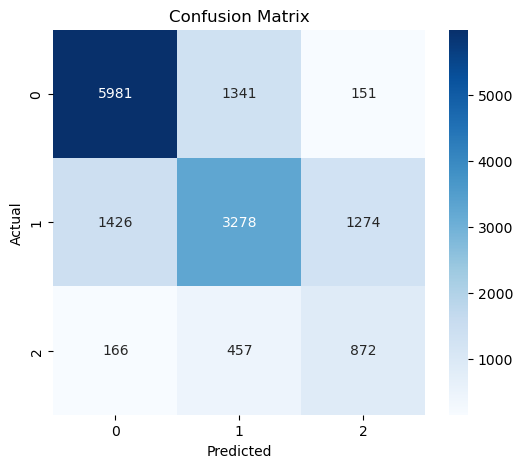

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [116]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

results = {}
roc_probs = {}

for name, model in models.items():
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
    
    results[name] = [acc, f1, auc]
    roc_probs[name] = y_prob

In [117]:
results_df = pd.DataFrame(
    results,
    index=["Accuracy", "F1 Score", "AUC"]
).T

print(results_df)

                     Accuracy  F1 Score       AUC
Logistic Regression  0.711963  0.694526  0.828562
Random Forest        0.720126  0.708207  0.832181
Gradient Boosting    0.720327  0.708905  0.838053
XGBoost              0.722133  0.710104  0.839785


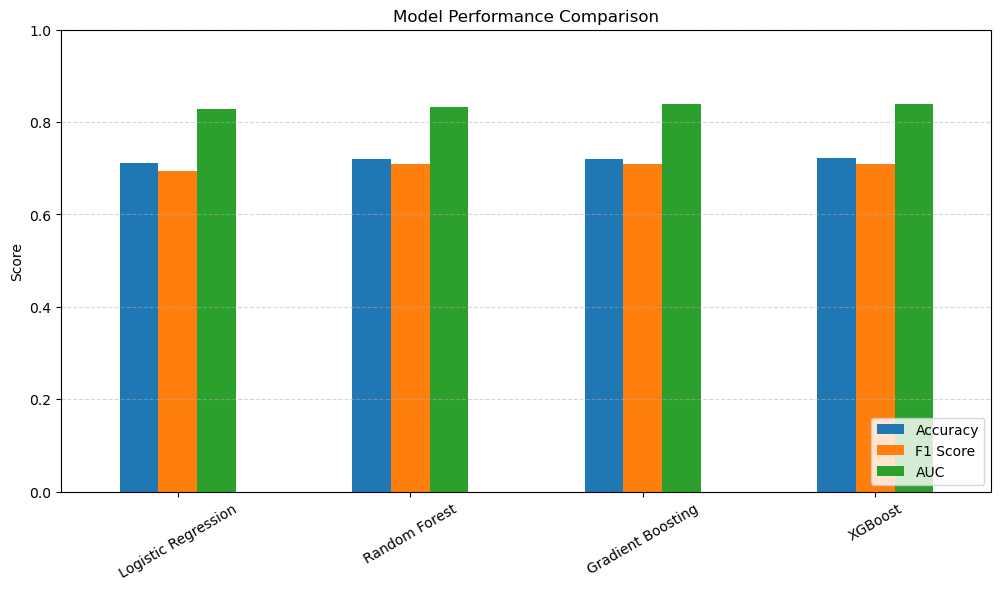

In [118]:
results_df.plot(kind='bar', figsize=(12,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

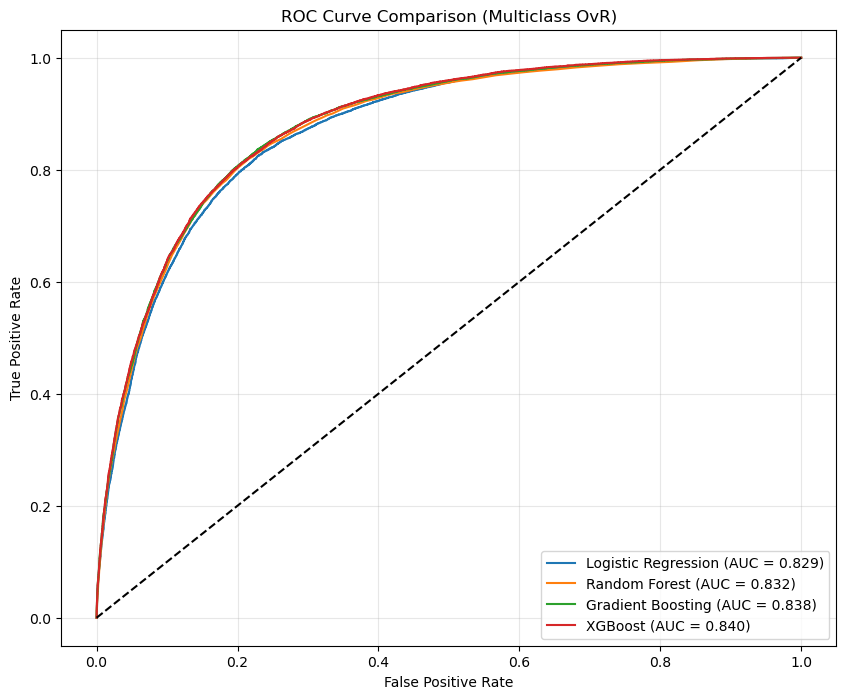

In [119]:
plt.figure(figsize=(10,8))

for name in models.keys():
    
    y_prob = roc_probs[name]
    
    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_prob.ravel()
    )
    
    auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr')
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Multiclass OvR)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

In [120]:
# =====================================
# Ordinal Classification (Manual Setup)
# =====================================

# Create ordinal binary targets
y_train_ge_1 = (y_train >= 1).astype(int)
y_train_ge_2 = (y_train >= 2).astype(int)

y_test_ge_1 = (y_test >= 1).astype(int)
y_test_ge_2 = (y_test >= 2).astype(int)

# Model for >=1
model_ge_1 = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=42
    ))
])

# Model for >=2
model_ge_2 = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=42
    ))
])

model_ge_1.fit(X_train, y_train_ge_1)
model_ge_2.fit(X_train, y_train_ge_2)

# Get probabilities
p_ge_1 = model_ge_1.predict_proba(X_test)[:, 1]
p_ge_2 = model_ge_2.predict_proba(X_test)[:, 1]

# Convert back to ordinal class prediction
y_pred_ordinal = np.zeros(len(y_test))

y_pred_ordinal[p_ge_1 >= 0.5] = 1
y_pred_ordinal[p_ge_2 >= 0.5] = 2

from sklearn.metrics import accuracy_score, classification_report

print("Ordinal Model Accuracy:", accuracy_score(y_test, y_pred_ordinal))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_ordinal))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_ordinal))

Ordinal Model Accuracy: 0.712431419777867

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.82      0.80      7473
           1       0.65      0.68      0.67      5978
           2       0.61      0.28      0.38      1495

    accuracy                           0.71     14946
   macro avg       0.68      0.59      0.61     14946
weighted avg       0.71      0.71      0.70     14946


Confusion Matrix:

[[6149 1305   19]
 [1649 4084  245]
 [ 196  884  415]]


Ordinal Model AUC: 0.827863492458779


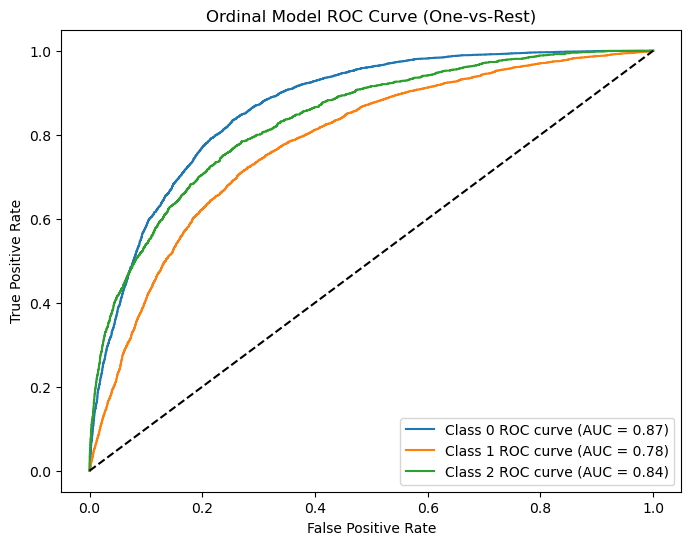

In [121]:
# =====================================
# Convert Ordinal Probabilities to Class Probabilities
# =====================================

prob_class0 = 1 - p_ge_1
prob_class1 = p_ge_1 - p_ge_2
prob_class2 = p_ge_2

y_prob_ordinal = np.vstack([prob_class0, prob_class1, prob_class2]).T

from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])

from sklearn.metrics import roc_auc_score

auc_ordinal = roc_auc_score(y_test_bin, y_prob_ordinal, multi_class='ovr')
print("Ordinal Model AUC:", auc_ordinal)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = 3
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_ordinal[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"Class {i} ROC curve (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Ordinal Model ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()


In [122]:
# ===============================
# Interaction Feature Engineering
# ===============================

# Work on a copy
df_interact = df_model.copy()

# Age × Chronic burden
df_interact['age_chronic_interaction'] = (
    df_interact['AGEY1X'] * df_interact['total_chronic_conditions']
)

# Insurance × ER visits
df_interact['ins_er_interaction'] = (
    df_interact['INSCOVY1'] * df_interact['ERTOTY1']
)

# Health status × Chronic burden
df_interact['health_chronic_interaction'] = (
    df_interact['RTHLTH1'] * df_interact['total_chronic_conditions']
)

# Poverty × Insurance
df_interact['income_ins_interaction'] = (
    df_interact['POVCATY1'] * df_interact['INSCOVY1']
)

# Update feature list
interaction_features = features + [
    'age_chronic_interaction',
    'ins_er_interaction',
    'health_chronic_interaction',
    'income_ins_interaction'
]

X_interact = df_interact[interaction_features]
y_interact = df_interact[target]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_interact, y_interact,
    test_size=0.2,
    random_state=42,
    stratify=y_interact
)

print("Interaction features added successfully.")

Interaction features added successfully.


In [123]:
# =====================================
# Train Model With Interaction Features
# =====================================

xgb_interaction_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=3,
        tree_method='hist',
        random_state=42
    ))
])

xgb_interaction_model.fit(X_train_i, y_train_i)

y_pred_i = xgb_interaction_model.predict(X_test_i)
y_prob_i = xgb_interaction_model.predict_proba(X_test_i)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Interaction Model Accuracy:", accuracy_score(y_test_i, y_pred_i))

print("\nClassification Report:\n")
print(classification_report(y_test_i, y_pred_i))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_i, y_pred_i))

Interaction Model Accuracy: 0.713970293054998

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.83      0.79      4982
           1       0.66      0.67      0.66      3986
           2       0.65      0.30      0.41       996

    accuracy                           0.71      9964
   macro avg       0.69      0.60      0.62      9964
weighted avg       0.71      0.71      0.70      9964


Confusion Matrix:

[[4159  812   11]
 [1177 2661  148]
 [ 152  550  294]]


In [124]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin_i = label_binarize(y_test_i, classes=[0,1,2])

auc_i = roc_auc_score(y_test_bin_i, y_prob_i, multi_class='ovr')

print("Interaction Model AUC:", auc_i)

Interaction Model AUC: 0.834545887426342


In [125]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier


# ===============================
# COMPUTE CLASS WEIGHTS
# ===============================

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)


# Convert weights for each training sample
sample_weights = y_train.map(class_weights)


# ===============================
# IMPROVED XGBOOST MODEL
# ===============================

xgb_model_improved = Pipeline([
    
    ('preprocess', preprocessor),
    
    ('model', XGBClassifier(
        
        objective='multi:softprob',
        num_class=len(classes),
        eval_metric='mlogloss',
        tree_method='hist',
        
        # Improved hyperparameters
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        
        n_jobs=-1,
        random_state=42
    ))
])


# ===============================
# TRAIN MODEL WITH SAMPLE WEIGHTS
# ===============================

xgb_model_improved.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)


# ===============================
# PREDICTIONS
# ===============================

y_pred = xgb_model_improved.predict(X_test)


# ===============================
# MODEL EVALUATION
# ===============================

print("\nIMPROVED XGBOOST MODEL")

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Class Weights: {np.int8(0): np.float64(0.6666666666666666), np.int8(1): np.float64(0.8333094384707288), np.int8(2): np.float64(3.3337157059554534)}

IMPROVED XGBOOST MODEL

Accuracy: 0.6778402248093135

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.80      0.80      7473
           1       0.65      0.55      0.59      5978
           2       0.38      0.58      0.46      1495

    accuracy                           0.68     14946
   macro avg       0.61      0.64      0.62     14946
weighted avg       0.69      0.68      0.68     14946


Confusion Matrix:

[[5981 1341  151]
 [1426 3278 1274]
 [ 166  457  872]]


Total Features After Encoding: 41


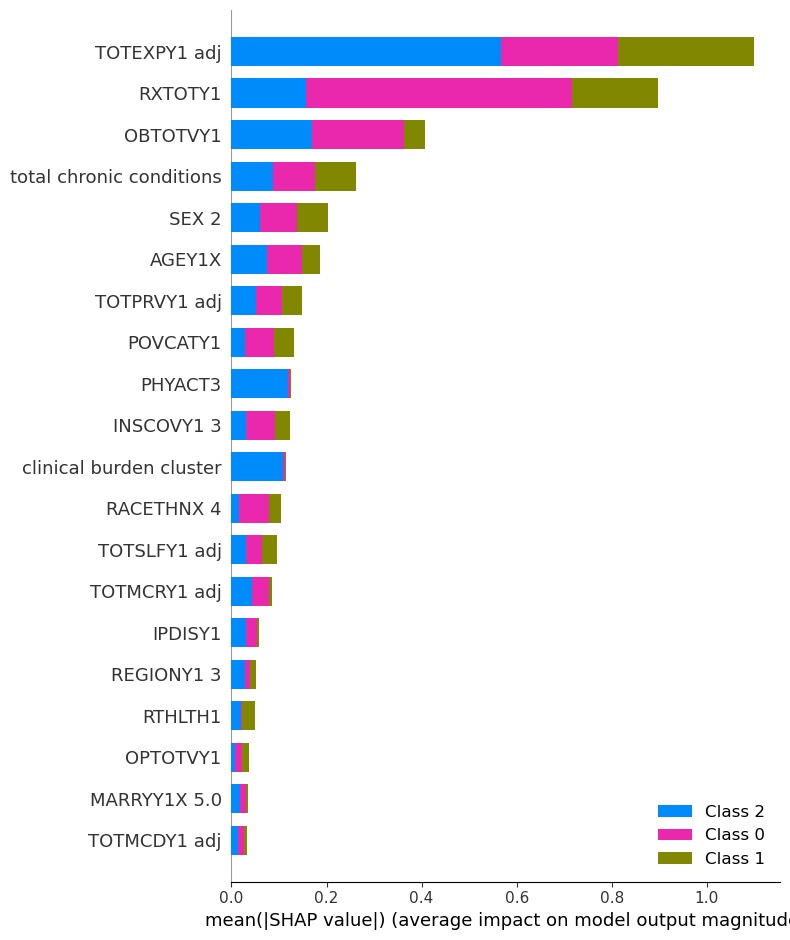

In [153]:
import shap

# ==========================================
# 2. EXTRACT TRAINED MODEL FROM PIPELINE
# ==========================================

xgb_model_trained = xgb_model.named_steps['model']
preprocessor_trained = xgb_model.named_steps['preprocess']


# ==========================================
# 3. TRANSFORM TRAINING DATA
# ==========================================

X_train_transformed = preprocessor_trained.transform(X_train)

# Convert sparse matrix to dense if needed
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()


# ==========================================
# 4. GET FEATURE NAMES AFTER PREPROCESSING
# ==========================================

feature_names = preprocessor_trained.get_feature_names_out()

print("Total Features After Encoding:", len(feature_names))


# ==========================================
# 5. CREATE SHAP EXPLAINER
# ==========================================

explainer = shap.TreeExplainer(xgb_model_trained)

shap_values = explainer.shap_values(X_train_transformed)

# ==========================================
# CLEAN FEATURE NAMES (AFTER getting names)
# ==========================================
import re

def clean_feature_name(name):
    name = re.sub(r'^(num__|cat__)', '', name)  # remove prefixes
    name = name.replace('_', ' ')               # make readable
    return name

clean_feature_names = [clean_feature_name(f) for f in feature_names]


# ==========================================
# SHAP PLOT (UPDATED)
# ==========================================
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=clean_feature_names,   # 👈 ONLY CHANGE HERE
    plot_type="bar"
)
